In [1]:
import sys
from scipy.stats import sem
sys.path.append(r'C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [10]:
activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(name="NDNF_E1A1B", new_NDNF=True)


fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[animal] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[animal] = activity_dict_NDNF_newest[animal]



In [84]:
def get_field_type_percents(clusters_dict_labelled_field_type, residual_activity_dict_EC):
    before_percent_list = []
    near_percent_list = []
    after_percent_list = []
    wraparound_percent_list = []
    noisy_percent_list = []

    animal_percent_dict = {}
    
    counter=0
    
    for animal in clusters_dict_labelled_field_type:
        cell_dict = {}

        for cell in clusters_dict_labelled_field_type[animal]:
            counter+=1
            total_num_trials = residual_activity_dict_EC[animal][cell].shape[1]

            # Initialize field type counts
            before_count = 0
            near_count = 0
            after_count = 0
            wraparound_count = 0
            noisy_count = 0
            
            

            for i in clusters_dict_labelled_field_type[animal][cell]:
                for field_type, trial_array in clusters_dict_labelled_field_type[animal][cell][i].items():
                    count = len(trial_array)
                    if field_type == "before_field":
                        before_count += count
                    elif field_type == "near_field":
                        near_count += count
                    elif field_type == "after_field":
                        after_count += count
                    elif field_type == "wraparound_field":
                        wraparound_count += count
                    elif field_type == "noisy_field":
                        noisy_count += count
            
            print(f"counter {counter} np.sum {np.sum([before_count, near_count, after_count, wraparound_count, noisy_count])} totals trials {total_num_trials}")
            
            if total_num_trials > 0:
                before_percent = before_count / total_num_trials * 100
                near_percent = near_count / total_num_trials * 100
                after_percent = after_count / total_num_trials * 100
                wraparound_percent = wraparound_count / total_num_trials * 100
                noisy_percent = noisy_count / total_num_trials * 100

                before_percent_list.append(before_percent)
                near_percent_list.append(near_percent)
                after_percent_list.append(after_percent)
                wraparound_percent_list.append(wraparound_percent)
                noisy_percent_list.append(noisy_percent)

                cell_dict[cell] = {
                    "before_percent": before_percent,
                    "near_percent": near_percent,
                    "after_percent": after_percent,
                    "wraparound_percent": wraparound_percent,
                    "noisy_percent": noisy_percent
                }

#                 print(f"{animal} {cell} → total trials: {total_num_trials} total labeled: {before_count + near_count + after_count + wraparound_count + noisy_count}")

        animal_percent_dict[animal] = cell_dict

    percent_lists = [
        before_percent_list,
        near_percent_list,
        after_percent_list,
        wraparound_percent_list,
        noisy_percent_list,
    ]

    return animal_percent_dict, percent_lists


In [97]:
animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, animal_TCA=False)
print(len(animal_first_changepoints_list[0][1]))

TypeError: object of type 'numpy.int64' has no len()

In [102]:
def get_field_type_percents2(clusters_dict_labelled_field_type, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="e"):
    before_percent_list = []
    near_percent_list = []
    after_percent_list = []
    wraparound_percent_list = []
    noisy_percent_list = []

    animal_percent_dict = {}
    
    counter=0
    
    animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, animal_TCA=False)

    
    for idx, animal in enumerate(clusters_dict_labelled_field_type):
        cell_dict = {}

        for idt, cell in enumerate(clusters_dict_labelled_field_type[animal]):
            counter+=1
#             total_num_trials = residual_activity_dict_EC[animal][cell].shape[1]
            
            if e_or_l=="e":
                total_num_trials = animal_first_changepoints_list[idx][idt]
            else:
                total_num_trials = animal_second_changepoints_list[idx][idt]
    
            # Initialize field type counts
            before_count = 0
            near_count = 0
            after_count = 0
            wraparound_count = 0
            noisy_count = 0
            
            

            for i in clusters_dict_labelled_field_type[animal][cell]:
                for field_type, trial_array in clusters_dict_labelled_field_type[animal][cell][i].items():
                    count = len(trial_array)
                    if field_type == "before_field":
                        before_count += count
                    elif field_type == "near_field":
                        near_count += count
                    elif field_type == "after_field":
                        after_count += count
                    elif field_type == "wraparound_field":
                        wraparound_count += count
                    elif field_type == "noisy_field":
                        noisy_count += count
            
#             print(f"counter {counter} np.sum {np.sum([before_count, near_count, after_count, wraparound_count, noisy_count])} totals trials {total_num_trials}")
            
            if total_num_trials > 0:
                before_percent = before_count / total_num_trials * 100
                near_percent = near_count / total_num_trials * 100
                after_percent = after_count / total_num_trials * 100
                wraparound_percent = wraparound_count / total_num_trials * 100
                noisy_percent = noisy_count / total_num_trials * 100

                before_percent_list.append(before_percent)
                near_percent_list.append(near_percent)
                after_percent_list.append(after_percent)
                wraparound_percent_list.append(wraparound_percent)
                noisy_percent_list.append(noisy_percent)

                cell_dict[cell] = {
                    "before_percent": before_percent,
                    "near_percent": near_percent,
                    "after_percent": after_percent,
                    "wraparound_percent": wraparound_percent,
                    "noisy_percent": noisy_percent
                }

                print(f"{animal} {cell} → total trials: {total_num_trials} total labeled: {before_count + near_count + after_count + wraparound_count + noisy_count}")

        animal_percent_dict[animal] = cell_dict

    percent_lists = [
        before_percent_list,
        near_percent_list,
        after_percent_list,
        wraparound_percent_list,
        noisy_percent_list,
    ]

    return animal_percent_dict, percent_lists


In [103]:
animal_percent_dict_EC_early_peak, percent_lists_EC_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC)


animal_1 cell_1 → total trials: 40 total labeled: 40
animal_1 cell_2 → total trials: 10 total labeled: 10
animal_1 cell_3 → total trials: 20 total labeled: 20
animal_1 cell_4 → total trials: 40 total labeled: 40
animal_1 cell_5 → total trials: 20 total labeled: 20
animal_1 cell_6 → total trials: 35 total labeled: 35
animal_1 cell_7 → total trials: 15 total labeled: 15
animal_1 cell_8 → total trials: 5 total labeled: 5
animal_1 cell_9 → total trials: 50 total labeled: 50
animal_1 cell_10 → total trials: 65 total labeled: 65
animal_1 cell_11 → total trials: 25 total labeled: 25
animal_1 cell_12 → total trials: 35 total labeled: 35
animal_1 cell_13 → total trials: 20 total labeled: 20
animal_1 cell_14 → total trials: 30 total labeled: 30
animal_1 cell_15 → total trials: 30 total labeled: 30
animal_1 cell_16 → total trials: 50 total labeled: 50
animal_1 cell_17 → total trials: 5 total labeled: 5
animal_1 cell_18 → total trials: 10 total labeled: 10
animal_1 cell_19 → total trials: 5 total 

In [91]:
counter=0
for animal in clusters_dict_labelled_field_type_early_EC_peak:
    for cell in clusters_dict_labelled_field_type_early_EC_peak[animal]:
        for i in clusters_dict_labelled_field_type_early_EC_peak[animal][cell][1]:
            print


AttributeError: 'dict' object has no attribute 'shape'

In [88]:
clusters_dict_labelled_field_type_early_EC_peak["animal_1"]["cell_2"][2]

{'after_field': array([[0.04511215, 0.05244768, 0.04140091, 0.04857966, 0.03804959,
         0.04984613, 0.04767707, 0.02510269, 0.05134242, 0.06312476,
         0.04799411, 0.07873865, 0.07729841, 0.11799412, 0.09634694,
         0.07589978, 0.05807825, 0.07561491, 0.06901565, 0.10192333,
         0.05471707, 0.06116349, 0.07250695, 0.06905257, 0.04130696,
         0.06628887, 0.06608389, 0.04859062, 0.0263076 , 0.03859667,
         0.03786443, 0.05239326, 0.07026006, 0.04278891, 0.04442611,
         0.03822401, 0.01948509, 0.02804524, 0.03502909, 0.04285478,
         0.04468856, 0.02520023, 0.03508535, 0.0247624 , 0.06473879,
         0.01327371, 0.0256253 , 0.0315047 , 0.02438066, 0.03387492],
        [0.04573979, 0.01107783, 0.04788448, 0.02440811, 0.00187819,
         0.02240796, 0.0200963 , 0.01318258, 0.00262105, 0.01547377,
         0.00410157, 0.009506  , 0.00943542, 0.00640068, 0.02287323,
         0.0126142 , 0.0369552 , 0.01933217, 0.02092067, 0.03836671,
         0.0058119

In [3]:

def get_cells_percents(animal_percent_dict_EC_early_peak, animal_percent_dict_EC_late_peak, animal_percent_dict_EC_early_trough, animal_percent_dict_EC_late_trough):
    
    count_early_peak_EC_before = get_count(animal_percent_dict_EC_early_peak, field_type="before_percent")
    count_late_peak_EC_before = get_count(animal_percent_dict_EC_late_peak, field_type="before_percent")

    count_early_trough_EC_before = get_count(animal_percent_dict_EC_early_trough, field_type="before_percent")
    count_late_trough_EC_before = get_count(animal_percent_dict_EC_late_trough, field_type="before_percent")

    count_early_peak_EC_near = get_count(animal_percent_dict_EC_early_peak, field_type="near_percent")
    count_late_peak_EC_near = get_count(animal_percent_dict_EC_late_peak, field_type="near_percent")

    count_early_trough_EC_near = get_count(animal_percent_dict_EC_early_trough, field_type="near_percent")
    count_late_trough_EC_near = get_count(animal_percent_dict_EC_late_trough, field_type="near_percent")

    count_early_peak_EC_after = get_count(animal_percent_dict_EC_early_peak, field_type="after_percent")
    count_late_peak_EC_after = get_count(animal_percent_dict_EC_late_peak, field_type="after_percent")

    count_early_trough_EC_after = get_count(animal_percent_dict_EC_early_trough, field_type="after_percent")
    count_late_trough_EC_after = get_count(animal_percent_dict_EC_late_trough, field_type="after_percent")

    count_early_peak_EC_wraparound = get_count(animal_percent_dict_EC_early_peak, field_type="wraparound_percent")
    count_late_peak_EC_wraparound = get_count(animal_percent_dict_EC_late_peak, field_type="wraparound_percent")

    count_early_trough_EC_wraparound = get_count(animal_percent_dict_EC_early_trough, field_type="wraparound_percent")
    count_late_trough_EC_wraparound = get_count(animal_percent_dict_EC_late_trough, field_type="wraparound_percent")

    count_early_peak_EC_noisy = get_count(animal_percent_dict_EC_early_peak, field_type="noisy_percent")
    count_late_peak_EC_noisy = get_count(animal_percent_dict_EC_late_peak, field_type="noisy_percent")

    count_early_trough_EC_noisy = get_count(animal_percent_dict_EC_early_trough, field_type="noisy_percent")
    count_late_trough_EC_noisy = get_count(animal_percent_dict_EC_late_trough, field_type="noisy_percent")
    
    percent_of_cells_list_EC_early_peak = [count_early_peak_EC_before, count_early_peak_EC_near, count_early_peak_EC_after, count_early_peak_EC_wraparound, count_early_peak_EC_noisy]
    percent_of_cells_list_EC_late_peak = [count_late_peak_EC_before, count_late_peak_EC_near, count_late_peak_EC_after, count_late_peak_EC_wraparound, count_late_peak_EC_noisy]

    percent_of_cells_list_EC_early_trough = [count_early_trough_EC_before, count_early_trough_EC_near, count_early_trough_EC_after, count_early_trough_EC_wraparound, count_early_trough_EC_noisy]
    percent_of_cells_list_EC_late_trough = [count_late_trough_EC_before, count_late_trough_EC_near, count_late_trough_EC_after, count_late_trough_EC_wraparound, count_late_trough_EC_noisy]

    return percent_of_cells_list_EC_early_peak, percent_of_cells_list_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough



In [13]:
def get_means_list(residual_activity_dict_EC):
    means_list = []
    trials_list_wraparound = []

    clusters_dict_labelled_field_type_wraparound = {}

    count=0

    for animal in residual_activity_dict_EC:
        cell_dict={}
        for cell in residual_activity_dict_EC[animal]:

            wraparound_field = {}

            data = residual_activity_dict_EC[animal][cell]
            trial_list = []

            for trial in range(data.shape[0] - 1):  # avoid out-of-bounds on next trial
                current_data = data[:, trial]
                next_data = data[:, trial+1]

                peak_current = np.argmax(current_data)
                peak_next = np.argmax(next_data)

                mean_current = np.mean(current_data)
                threshold_current = 1.5*mean_current
                mean_next = np.mean(current_data)
                threshold_next = 1.5*mean_next

                if peak_current > 45 and peak_next < 5 and peak_current>threshold_current and peak_next>threshold_next:
                    trial_list.append(trial)
                    means_list.append(np.mean(residual_activity_dict_EC[animal][cell][:,trial]))
                    trials_list_wraparound.append(residual_activity_dict_EC[animal][cell][:,trial])
                    means_list.append(np.mean(residual_activity_dict_EC[animal][cell][:,trial+1]))
                    trials_list_wraparound.append(residual_activity_dict_EC[animal][cell][:,trial+1])

            cell_dict[cell] = trial_list

        clusters_dict_labelled_field_type_wraparound[animal] = cell_dict

    
    return means_list


# means_list_EC = get_means_list(residual_activity_dict_EC)
# means_list_SST = get_means_list(residual_activity_dict_SST)
# means_list_NDNF = get_means_list(residual_activity_dict_NDNF_new)

means_list_EC = get_means_list(residual_activity_dict_EC)
means_list_SST = get_means_list(residual_activity_dict_SST)
means_list_NDNF = get_means_list(residual_activity_dict_NDNF_newest)

In [14]:
# clusters=3
# cell_num=1
# animal_num=1


def get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing"):

    clusters_dict_EC = {}

    for animal_num, animal in enumerate(residual_activity_dict_EC):
        clusters_cell_EC = {}
        for cell_num, cell in enumerate(residual_activity_dict_EC[animal]):
#             cell_num = int(cell.split("_")[-1])  # e.g., from 'cell_3' -> 3
#             elbow_kmeans = get_elbow_score_data(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
            # ✅ skip if cell is missing in model dict
            try:
                elbow_kmeans = get_elbow_score_data(
                    testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell,
                    animal=animal_num,
                    cell=cell_num
                )
            except KeyError:
                print(f"⚠️ Skipping animal {animal_num}, cell {cell_num} — not in model dict")
                continue

#             elbow_kmeans = get_elbow_score_data(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
            clusters = elbow_kmeans+1
            clusters_list = plot_per_cell_clustering_internals_single_cluster(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal_id=animal_num, cell_id=cell_num, num_clusters=clusters, plot=False, early_late_nothing=eln)
            clusters_cell_EC[cell] = clusters_list

        clusters_dict_EC[animal] = clusters_cell_EC
        
    return clusters_dict_EC

# clusters=3
# cell_num=1
# animal_num=1


def get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing"):

    clusters_dict_EC = {}

    for animal_num, animal in enumerate(residual_activity_dict_EC):
        clusters_cell_EC = {}
        for cell_num, cell in enumerate(residual_activity_dict_EC[animal]):
#             cell_num = int(cell.split("_")[-1])  # e.g., from 'cell_3' -> 3
#             elbow_kmeans = get_elbow_score_data(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
            # ✅ skip if cell is missing in model dict
            try:
                elbow_kmeans = get_elbow_score_data(
                    testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell,
                    animal=animal_num,
                    cell=cell_num
                )
            except KeyError:
                print(f"⚠️ Skipping animal {animal_num}, cell {cell_num} — not in model dict")
                continue

#             elbow_kmeans = get_elbow_score_data(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
            clusters = elbow_kmeans+1
            clusters_list = plot_per_cell_clustering_internals_single_cluster(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal_id=animal_num, cell_id=cell_num, num_clusters=clusters, plot=False, early_late_nothing=eln)
            clusters_cell_EC[cell] = clusters_list

        clusters_dict_EC[animal] = clusters_cell_EC
        
    return clusters_dict_EC



In [15]:
import operator

def get_clusters_dict_field_type(means_list, clusters_dict_EC, residual_activity_dict_EC, use_peak=True):

    rounded_means_set = set(round(m, 5) for m in means_list)


    # for animal in clusters_dict_EC:
    #     for cell in clusters_dict_EC[animal]:

    overall_animal_cluster_trial_averages = {}

    clusters_dict_labelled_field_type = {}


    for animal in clusters_dict_EC:
        cell_dict = {}
        cell_dict_labelled = {}
        for cell in clusters_dict_EC[animal]:
            cell_data = clusters_dict_EC[animal][cell]
            num_clusters = len(cell_data)
            before_field = {}
            near_field = {}
            after_field = {}
            noisy_field = {}
            wraparound_field = {}

            total_num_trials = residual_activity_dict_EC[animal][cell].shape[1]

            count= 0

            clusters_dict = {}
            for i in range(num_clusters):

                cluster_length = cell_data[i].shape[0]
                count+= cluster_length

                trial_av = np.mean(cell_data[i], axis=0)
                if len(trial_av)>0:
                    if use_peak:
                        peak = np.argmax(trial_av)
                        peak_amp = max(trial_av)
                        compare_op = operator.gt  
                        
                    else:
                        peak = np.argmin(trial_av)
                        peak_amp = min(trial_av)
                        compare_op = operator.lt
                        
                    mean_trial_av = np.mean(trial_av)
#                     cutoff = mean_trial_av * 1.5
                    
                    if use_peak:
                        cutoff = mean_trial_av * 0.8
                    else:
                        cutoff = mean_trial_av * 2.0  # Or whatever gets you a stricter min threshold

                    if compare_op(peak_amp, cutoff):          
                        if peak <=15:   
                            filtered_trials = []
                            wraparound_trials = []

                            for trial in cell_data[i]:
                                trial_data = trial  
                                mean_trial_data = np.mean(trial_data)

                                if round(mean_trial_data, 5) in rounded_means_set:
                                    wraparound_trials.append(trial_data)
                                else:
                                    filtered_trials.append(trial_data)

                            filtered_array = np.array(filtered_trials)
                            wraparound_array = np.array(wraparound_trials)

                            clusters_dict[i] = {f"before_field":filtered_array,
                                               "wraparound_field":wraparound_array}
                            before_field[i] = filtered_array
                            wraparound_field[i] = wraparound_array
                            
                        elif 15 < peak < 35:
                            filtered_trials = []
                            wraparound_trials = []

                            for trial in cell_data[i]:
                                trial_data = trial  
                                mean_trial_data = np.mean(trial_data)

                                if round(mean_trial_data, 5) in rounded_means_set:
                                    wraparound_trials.append(trial_data)
                                else:
                                    filtered_trials.append(trial_data)

                            filtered_array = np.array(filtered_trials)
                            wraparound_array = np.array(wraparound_trials)

                            clusters_dict[i] = {f"near_field":filtered_array,
                                               "wraparound_field":wraparound_array}
                            
                            near_field[i] = filtered_array
                            wraparound_field[i] = wraparound_array

                        elif peak >=35:                      
                            filtered_trials = []
                            wraparound_trials = []

                            for trial in cell_data[i]:
                                trial_data = trial  
                                mean_trial_data = np.mean(trial_data)

                                mean_trial_data = np.mean(trial_data)
                                if round(mean_trial_data, 5) in rounded_means_set:
                                    wraparound_trials.append(trial_data)
                                else:
                                    filtered_trials.append(trial_data)

                            filtered_array = np.array(filtered_trials)
                            wraparound_array = np.array(wraparound_trials)

                            clusters_dict[i] = {f"after_field":filtered_array,
                                               "wraparound_field":wraparound_array}
                            
                            after_field[i] = filtered_array
                            wraparound_field[i] = wraparound_array

                    else:
                        filtered_trials = []
                        wraparound_trials = []

                        for trial in cell_data[i]:
                            trial_data = trial
                            mean_trial_data = np.mean(trial_data)

                            if round(mean_trial_data, 5) in rounded_means_set:
                                wraparound_trials.append(trial_data)
                            else:
                                filtered_trials.append(trial_data)

                        if len(filtered_trials) > 0:
                            filtered_array = np.array(filtered_trials)
                            wraparound_array = np.array(wraparound_trials)

                            noisy_field[i] = filtered_array
                            wraparound_field[i] = wraparound_array
                            clusters_dict[i] = {"noisy_field": filtered_array,
                                                "wraparound_field": wraparound_array}

#                         print(f"Potential noisy: {animal} cell {cell} cluster {i} with amp={peak_amp:.2f}, mean={mean_trial_av:.2f}, cutoff={cutoff:.2f}")

#                         if len(filtered_trials) > 0:
#                             filtered_array = np.array(filtered_trials)
#                             noisy_field[i] = filtered_array
#                             clusters_dict[i] = {"noisy_field": filtered_array}

# #                         filtered_trials = []
# #                         wraparound_trials = []

# #                         for trial in cell_data[i]:
# #                             trial_data = trial  
# #                             mean_trial_data = np.mean(trial_data)

# #                             mean_trial_data = np.mean(trial_data)
# #                             if round(mean_trial_data, 5) in rounded_means_set:
# #                                 wraparound_trials.append(trial_data)
# #                             else:
# #                                 filtered_trials.append(trial_data)

# #                         filtered_array = np.array(filtered_trials)
# #                         wraparound_array = np.array(wraparound_trials)

# #                         clusters_dict[i] = {f"noisy_field":filtered_array, 
# #                                            "wraparound_field": wraparound_array}
                        
#                             noisy_field[i] = filtered_array
#                             wraparound_field[i] = wraparound_array
            
            cells_dict = {"before_field":before_field,
                            "near_field":near_field,
                            "after_field": after_field, 
                             "noisy_field": noisy_field,
                             "wraparound_field": wraparound_field}
        
            cell_dict[cell] = cells_dict
    

            cell_dict_labelled[cell] = clusters_dict
            print(f" count {count} total {total_num_trials}")
        clusters_dict_labelled_field_type[animal] = cell_dict_labelled
        overall_animal_cluster_trial_averages[animal] = cell_dict       


    return clusters_dict_labelled_field_type, overall_animal_cluster_trial_averages


In [16]:
def plot_per_cell_clustering_internals_single_cluster(cell_EC_model_ranks20_contig_x00, cell_NDNF_model_ranks20_kmeans_reassign_umap_x00, residual_activity_dict_NDNF, animal_id=1, cell_id=1, num_clusters=4, plot=True, early_late_nothing="nothing"):
    
    animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_EC_model_ranks20_contig_x00, residual_activity_dict_NDNF, animal_TCA=False)

    
    tensor_list_by_animal_all_NDNF = []
    for animal in residual_activity_dict_NDNF:
        neural_data = ut.get_animal_neural_tensor(residual_activity_dict_NDNF, animal=animal)
        neural_data_tensor = torch.tensor(neural_data)
        # Normalize per cell
        for i in range(neural_data_tensor.shape[1]):
            cell = neural_data_tensor[:, i, :]
            min_val = cell.min()
            max_val = cell.max()
            neural_data_tensor[:, i, :] = (cell - min_val) / (max_val - min_val + 1e-8)
        tensor_list_by_animal_all_NDNF.append(neural_data_tensor)

    real_activity = tensor_list_by_animal_all_NDNF[animal_id][:, cell_id, :].detach().numpy()

    #     for culsters_chosen in cell_NDNF_model_ranks20_kmeans_reassign_umap_x00[20][animal_id][cell_id][1][f"cell_{cell_id}"]["TCA_reconstructions_dict"]:

    TCA_reco = cell_NDNF_model_ranks20_kmeans_reassign_umap_x00[20][animal_id][cell_id][1][f"cell_{cell_id}"]["TCA_reconstructions_dict"][f"clusters_chosen_{num_clusters}"]

    animal_reco = cell_NDNF_model_ranks20_kmeans_reassign_umap_x00[20][animal_id][cell_id][1][f"cell_{cell_id}"]["Recon_by_cluster_av_dict"][f"clusters_chosen_{num_clusters}"]

    indices_dict = cell_NDNF_model_ranks20_kmeans_reassign_umap_x00[20][animal_id][cell_id][1][f"cell_{cell_id}"]["indices_for_cluster_number"][f"clusters_chosen_{num_clusters}"]

    if plot:
        fig, axs = plt.subplots(1, 3, figsize=(20, 10))
        im1 = (axs[0].imshow(real_activity, aspect='auto', vmin=0, vmax=1))
        axs[0].set_title("Raw Data")
        fig.colorbar(im1, ax=axs[0])
        im2 = axs[1].imshow(TCA_reco, aspect='auto', vmin=0, vmax=1)
        fig.colorbar(im2, ax=axs[1])
        im3 = axs[2].imshow(animal_reco, aspect='auto', vmin=0, vmax=1)
        fig.colorbar(im3, ax=axs[2])
        axs[1].set_title("SliceTCA Reconstruction")
        axs[2].set_title("Cluster Average Reconstruction")
        plt.tight_layout()
        plt.show()

    num_clusters = len(indices_dict)
    clusters_list = []

    if plot:
        fig, axs = plt.subplots(2, num_clusters, figsize=(num_clusters * 4, 6), squeeze=False)

    for n in range(num_clusters):
        indices = indices_dict[n]

        if early_late_nothing == "nothing":
            indices_list = indices
        elif early_late_nothing == "early":
            indices_list = [i for i in indices if i < animal_first_changepoints_list[animal_id][cell_id]]
        elif early_late_nothing == "late":
            indices_list = [i for i in indices if i > animal_second_changepoints_list[animal_id][cell_id]]
        else:
            raise ValueError(f"Invalid value for early_late_nothing: {early_late_nothing}")

        cluster = real_activity[indices_list, :]
        clusters_list.append(cluster)



#         cluster = real_activity[indices_list, :]  # trials x bins
#         clusters_list.append(cluster)


        if plot:
            axs[0, n].imshow(cluster, aspect='auto', vmin=0, vmax=1)
            axs[0, n].set_title(f"Cluster {n}")
            axs[0, n].set_xlabel("Position")
            axs[0, n].set_ylabel("Trial")

            # Plot the cluster mean
            axs[1, n].plot(np.mean(cluster, axis=0))
            axs[1, n].set_xlabel("Position")
            axs[1, n].set_ylabel("Mean activity")
            axs[1, n].set_ylim(0, 1)
    if plot:
        plt.tight_layout()
        plt.show()

    return clusters_list


In [17]:
############# data loading -- contiguous cell 

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_NDNF_model_ranks20_contig_x00_cells"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)



############## new NDNF
mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\cell_new_NDNF_model_ranks20_contiguous_x00_cell"
cell_new_NDNF_model_ranks20_contiguous_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell = {20: {}}
fixed_cell_NDNF_model_ranks20_contiguous_x00_cell = {20: {}}

for idx, animal in enumerate(cell_new_NDNF_model_ranks20_contiguous_x00_cell[20]):
    if idx > 8:
        fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell[20][animal] = cell_new_NDNF_model_ranks20_contiguous_x00_cell[20][animal]
        fixed_cell_NDNF_model_ranks20_contiguous_x00_cell[20][animal] = cell_new_NDNF_model_ranks20_contiguous_x00_cell[20][animal]
        
for animal in cell_NDNF_model_ranks20_contig_x00[20]:
    fixed_cell_combined_NDNF_model_ranks20_contiguous_x00_cell[20][f"old_{animal}"] = cell_NDNF_model_ranks20_contig_x00[20][animal]
    
    
    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_new_NDNF_model_ranks20_contiguous_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]
        
    
    

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 14 cells
    Animal 1: 14 cells
    Animal 2: 6 cells
    Animal 3: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
  

In [18]:
################ clusters must be of size 3+

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_OLD_NDNF_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_OLD_NDNF_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM\datasets\real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell"
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]
        


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 14 cells
    Animal 1: 14 cells
    Animal 2: 6 cells
    Animal 3: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 10 cells
    Animal 1: 8 cells
    Animal 2: 7 cells
    Animal 3: 7 cells
    Animal 4: 8 cells
    Animal 5: 9 cells
    Animal 6: 11 cells
    Animal 7: 6 cells
    Animal 8: 7 cells
    Animal 9: 10 cells
    Animal 10: 8 cells
    Animal 11: 7 cells
    Animal 12: 7 cells
    Animal 13: 8 cells
    Animal 14: 9 cells
    Animal 15: 11 cells
    Ani

In [23]:
fixed_NDNF_new_residual_dict = {}

for animal in residual_activity_dict_NDNF_new:
    animal_num = int(animal.split("_")[-1])
    if animal_num > 9:
        new_cell_dict = {}
        for cell in residual_activity_dict_NDNF_new[animal]:
            new_cell_dict[cell] = residual_activity_dict_NDNF_new[animal][cell]

        fixed_NDNF_new_residual_dict[animal] = new_cell_dict


def split_data(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell):
    fixed_model_NDNF_dict = {20:{}}
    testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20]
    for idx, animal in enumerate(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20]):
        if animal>8:
            fixed_model_NDNF_dict[20][idx-9] = testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell[20][animal]

    return fixed_model_NDNF_dict
fixed_model_NDNF_dict = split_data(testing_cell_super_new_NDNF_model_ranks20_reassign_regkmean_x00_cell)
NDNF_contig_new_fixed = split_data(cell_new_NDNF_model_ranks20_contiguous_x00_cell)

In [19]:
def get_count(animal_percent_dict_EC_early_peak, field_type="before_percent"):
    count_early = 0
    total_count = 0
    for animal in animal_percent_dict_EC_early_peak: #['animal_1']['cell_2']["before_percent"]:
        for cell in animal_percent_dict_EC_early_peak[animal]:
            if animal_percent_dict_EC_early_peak[animal][cell][field_type] > 0.0:
                count_early+=1
                
            if animal_percent_dict_EC_early_peak[animal][cell]:
                total_count+=1
    
    probability = count_early / total_count
    
    return probability
      

In [25]:
clusters_dict_SST_early = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="early")
clusters_dict_SST_late = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="late")
clusters_dict_SST_overall = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="nothing")


In [26]:
clusters_dict_EC_early = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="early")
clusters_dict_EC_late = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="late")
clusters_dict_EC_overall = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")


In [24]:
clusters_dict_NDNF_early = get_clusters_dict(NDNF_contig_new_fixed, fixed_model_NDNF_dict, fixed_NDNF_new_residual_dict, eln="early")
clusters_dict_NDNF_late = get_clusters_dict(NDNF_contig_new_fixed, fixed_model_NDNF_dict, fixed_NDNF_new_residual_dict, eln="late")
clusters_dict_NDNF_overall = get_clusters_dict(NDNF_contig_new_fixed, fixed_model_NDNF_dict, fixed_NDNF_new_residual_dict, eln="nothing")


clusters_dict_NDNF_early = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="early")
clusters_dict_NDNF_late = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="late")
clusters_dict_NDNF_overall = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="nothing")


In [28]:
clusters_dict_labelled_field_type_early_NDNF_peak, overall_animal_cluster_trial_averages_NDNF_peak_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_early, fixed_NDNF_new_residual_dict, use_peak=True)
clusters_dict_labelled_field_type_late_NDNF_peak, overall_animal_cluster_trial_averages_NDNF_peak_late = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_late, fixed_NDNF_new_residual_dict, use_peak=True)

clusters_dict_labelled_field_type_early_NDNF_overall, overall_animal_cluster_trial_averages_NDNF_overall_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_overall, fixed_NDNF_new_residual_dict, use_peak=True)
clusters_dict_labelled_field_type_late_NDNF_overall, overall_animal_cluster_trial_averages_NDNF_overall_late = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_overall, fixed_NDNF_new_residual_dict, use_peak=True)

clusters_dict_labelled_field_type_early_NDNF_trough, overall_animal_cluster_trial_averages_NDNF_trough_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_early, fixed_NDNF_new_residual_dict, use_peak=False)
clusters_dict_labelled_field_type_late_NDNF_trough, overall_animal_cluster_trial_averages_NDNF_trough_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_late, fixed_NDNF_new_residual_dict, use_peak=False)




 count 5 total 390
 count 60 total 390
 count 20 total 390
 count 5 total 390
 count 5 total 390
 count 5 total 390
 count 115 total 390
 count 5 total 390
 count 25 total 390
 count 100 total 390
 count 15 total 172
 count 30 total 172
 count 30 total 172
 count 65 total 172
 count 45 total 172
 count 40 total 172
 count 30 total 172
 count 30 total 172
 count 10 total 162
 count 75 total 162
 count 50 total 162
 count 80 total 162
 count 15 total 162
 count 25 total 162
 count 10 total 162
 count 20 total 116
 count 15 total 116
 count 15 total 116
 count 20 total 116
 count 100 total 116
 count 15 total 116
 count 70 total 116
 count 5 total 180
 count 30 total 180
 count 50 total 180
 count 80 total 180
 count 20 total 180
 count 20 total 180
 count 30 total 180
 count 20 total 180
 count 85 total 122
 count 50 total 122
 count 35 total 122
 count 5 total 122
 count 10 total 122
 count 10 total 122
 count 30 total 122
 count 80 total 122
 count 5 total 122
 count 45 total 128
 coun

In [29]:
clusters_dict_labelled_field_type_early_SST_peak, overall_animal_cluster_trial_averages_SST_peak_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_early, residual_activity_dict_SST, use_peak=True)
clusters_dict_labelled_field_type_late_SST_peak, overall_animal_cluster_trial_averages_SST_peak_late = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_late, residual_activity_dict_SST, use_peak=True)

clusters_dict_labelled_field_type_early_SST_overall, overall_animal_cluster_trial_averages_SST_overall_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_overall, residual_activity_dict_SST, use_peak=True)
clusters_dict_labelled_field_type_late_SST_overall, overall_animal_cluster_trial_averages_SST_overall_late = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_overall, residual_activity_dict_SST, use_peak=True)

clusters_dict_labelled_field_type_early_SST_trough, overall_animal_cluster_trial_averages_SST_trough_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_early, residual_activity_dict_SST, use_peak=False)
clusters_dict_labelled_field_type_late_SST_trough, overall_animal_cluster_trial_averages_SST_trough_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_late, residual_activity_dict_SST, use_peak=False)



# clusters_dict_labelled_field_type_overall_SST = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST, residual_activity_dict_SST)

 count 15 total 212
 count 10 total 212
 count 35 total 212
 count 10 total 212
 count 90 total 212
 count 35 total 152
 count 10 total 152
 count 65 total 152
 count 35 total 152
 count 115 total 152
 count 115 total 152
 count 25 total 152
 count 60 total 152
 count 25 total 152
 count 40 total 152
 count 25 total 152
 count 60 total 152
 count 45 total 152
 count 30 total 152
 count 15 total 152
 count 5 total 73
 count 15 total 73
 count 15 total 73
 count 25 total 73
 count 15 total 73
 count 15 total 73
 count 20 total 137
 count 15 total 137
 count 15 total 137
 count 20 total 137
 count 50 total 63
 count 40 total 63
 count 10 total 63
 count 30 total 63
 count 40 total 63
 count 15 total 63
 count 30 total 63
 count 10 total 63
 count 5 total 63
 count 10 total 63
 count 40 total 63
 count 15 total 63
 count 30 total 63
 count 85 total 163
 count 25 total 163
 count 40 total 163
 count 75 total 163
 count 15 total 163
 count 50 total 163
 count 75 total 163
 count 20 total 163

In [30]:
clusters_dict_labelled_field_type_early_EC_peak, overall_animal_cluster_trial_averages_EC_peak_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_early, residual_activity_dict_EC, use_peak=True)
clusters_dict_labelled_field_type_late_EC_peak, overall_animal_cluster_trial_averages_EC_peak_late = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_late, residual_activity_dict_EC, use_peak=True)

clusters_dict_labelled_field_type_early_EC_overall, overall_animal_cluster_trial_averages_EC_overall_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_overall, residual_activity_dict_EC, use_peak=True)
clusters_dict_labelled_field_type_late_EC_overall, overall_animal_cluster_trial_averages_EC_overall_late = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_overall, residual_activity_dict_EC, use_peak=True)

clusters_dict_labelled_field_type_early_EC_trough, overall_animal_cluster_trial_averages_EC_trough_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_early, residual_activity_dict_EC, use_peak=False)
clusters_dict_labelled_field_type_late_EC_trough, overall_animal_cluster_trial_averages_EC_trough_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_late, residual_activity_dict_EC, use_peak=False)



# clusters_dict_labelled_field_type_overall_EC = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC, residual_activity_dict_EC)

 count 40 total 78
 count 10 total 78
 count 20 total 78
 count 40 total 78
 count 20 total 78
 count 35 total 78
 count 15 total 78
 count 5 total 78
 count 50 total 78
 count 65 total 78
 count 25 total 78
 count 35 total 78
 count 20 total 78
 count 30 total 78
 count 30 total 78
 count 50 total 78
 count 5 total 78
 count 10 total 78
 count 5 total 78
 count 50 total 78
 count 40 total 78
 count 45 total 78
 count 20 total 78
 count 45 total 78
 count 5 total 78
 count 5 total 78
 count 60 total 78
 count 15 total 78
 count 5 total 78
 count 5 total 78
 count 10 total 78
 count 5 total 78
 count 25 total 78
 count 15 total 78
 count 5 total 78
 count 20 total 78
 count 20 total 78
 count 55 total 78
 count 50 total 78
 count 55 total 78
 count 40 total 78
 count 60 total 78
 count 15 total 78
 count 25 total 78
 count 55 total 78
 count 5 total 78
 count 40 total 78
 count 20 total 78
 count 45 total 78
 count 55 total 78
 count 5 total 78
 count 25 total 78
 count 45 total 78
 cou

 count 90 total 145
 count 105 total 145
 count 40 total 145
 count 25 total 145
 count 55 total 145
 count 25 total 145
 count 115 total 145
 count 80 total 145
 count 5 total 145
 count 5 total 145
 count 25 total 145
 count 25 total 145
 count 95 total 145
 count 5 total 58
 count 15 total 58
 count 10 total 58
 count 10 total 58
 count 5 total 58
 count 5 total 58
 count 10 total 58
 count 15 total 58
 count 5 total 58
 count 10 total 58
 count 30 total 58
 count 5 total 58
 count 5 total 58
 count 5 total 58
 count 30 total 58
 count 10 total 58
 count 5 total 58
 count 5 total 58
 count 35 total 58
 count 10 total 58
 count 30 total 58
 count 5 total 58
 count 5 total 58
 count 5 total 58
 count 5 total 58
 count 15 total 58
 count 5 total 58
 count 10 total 58
 count 5 total 58
 count 5 total 58
 count 15 total 58
 count 5 total 58
 count 5 total 58
 count 30 total 58
 count 10 total 58
 count 5 total 58
 count 10 total 58
 count 45 total 58
 count 5 total 58
 count 40 total 58


 count 28 total 64
 count 13 total 64
 count 8 total 64
 count 13 total 64
 count 33 total 64
 count 38 total 64
 count 13 total 64
 count 3 total 64
 count 13 total 64
 count 13 total 64
 count 13 total 64
 count 13 total 64
 count 23 total 64
 count 3 total 64
 count 3 total 64
 count 18 total 64
 count 38 total 64
 count 38 total 64
 count 13 total 64
 count 33 total 64
 count 18 total 64
 count 18 total 64
 count 18 total 64
 count 3 total 64
 count 3 total 64
 count 8 total 64
 count 8 total 64
 count 33 total 64
 count 8 total 64
 count 13 total 64
 count 18 total 64
 count 3 total 64
 count 28 total 64
 count 28 total 64
 count 3 total 64
 count 3 total 64
 count 3 total 64
 count 94 total 145
 count 39 total 145
 count 134 total 145
 count 4 total 145
 count 79 total 145
 count 129 total 145
 count 119 total 145
 count 59 total 145
 count 114 total 145
 count 84 total 145
 count 79 total 145
 count 84 total 145
 count 79 total 145
 count 129 total 145
 count 4 total 145
 count 

 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 66 total 66
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 total 63
 count 63 to

 count 101 total 101
 count 101 total 101
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 78 total 78
 count 7

 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 total 64
 count 64 to

 count 25 total 66
 count 5 total 66
 count 5 total 66
 count 10 total 66
 count 5 total 66
 count 15 total 66
 count 5 total 66
 count 20 total 66
 count 5 total 66
 count 5 total 66
 count 5 total 66
 count 5 total 66
 count 20 total 66
 count 35 total 66
 count 35 total 66
 count 5 total 66
 count 5 total 66
 count 30 total 63
 count 45 total 63
 count 10 total 63
 count 5 total 63
 count 40 total 63
 count 45 total 63
 count 5 total 63
 count 10 total 63
 count 25 total 63
 count 30 total 63
 count 30 total 63
 count 15 total 63
 count 45 total 63
 count 30 total 63
 count 45 total 63
 count 30 total 63
 count 5 total 63
 count 45 total 63
 count 30 total 63
 count 15 total 63
 count 45 total 63
 count 35 total 63
 count 30 total 63
 count 50 total 63
 count 15 total 63
 count 35 total 63
 count 55 total 63
 count 5 total 63
 count 5 total 63
 count 10 total 63
 count 5 total 63
 count 40 total 63
 count 20 total 63
 count 5 total 63
 count 5 total 63
 count 5 total 63
 count 5 tot

 count 45 total 66
 count 45 total 66
 count 5 total 66
 count 10 total 66
 count 5 total 66
 count 45 total 66
 count 10 total 66
 count 35 total 66
 count 50 total 66
 count 10 total 66
 count 35 total 66
 count 35 total 66
 count 5 total 66
 count 20 total 66
 count 45 total 66
 count 20 total 66
 count 30 total 66
 count 35 total 66
 count 5 total 66
 count 50 total 66
 count 5 total 66
 count 5 total 66
 count 5 total 66
 count 25 total 66
 count 40 total 66
 count 20 total 66
 count 40 total 66
 count 45 total 66
 count 25 total 66
 count 15 total 66
 count 5 total 66
 count 55 total 66
 count 35 total 66
 count 15 total 66
 count 20 total 66
 count 5 total 66
 count 5 total 66
 count 20 total 66
 count 30 total 66
 count 20 total 66
 count 5 total 66
 count 15 total 66
 count 10 total 66
 count 5 total 66
 count 50 total 66
 count 10 total 66
 count 40 total 66
 count 55 total 66
 count 50 total 66
 count 5 total 66
 count 10 total 66
 count 5 total 66
 count 40 total 66
 count 

In [31]:
def plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="near_field", plot=False):

    near_field_list = []

    for animal in clusters_dict_labelled_field_type_early_SST_trough:
        for cell in clusters_dict_labelled_field_type_early_SST_trough[animal]:
            for i in clusters_dict_labelled_field_type_early_SST_trough[animal][cell]:
                entry = clusters_dict_labelled_field_type_early_SST_trough[animal][cell][i]
                if field_type in entry:
                    arr = entry[field_type]
                    if len(arr) == 0:
                        continue  # skip empty arrays
                
                if field_type in clusters_dict_labelled_field_type_early_SST_trough[animal][cell][i]:
                    means = np.mean(clusters_dict_labelled_field_type_early_SST_trough[animal][cell][i][field_type], axis=0)
                    if means.shape != (50,):
                        continue

                    near_field_list.append(means) 
    
    near_field_array = np.array(near_field_list)
    
    if plot:
    
        for i in near_field_list:
            plt.plot(i, color='gray')
        plt.plot(np.mean(near_field_array, axis=0), color='red')
        plt.show()

        mean_near_field_array = np.mean(near_field_array, axis=0)
        sem_near_field_array = sem(near_field_array, axis=0)

        plt.plot(mean_near_field_array)
        plt.fill_between(range(len(mean_near_field_array)), mean_near_field_array-sem_near_field_array, mean_near_field_array+sem_near_field_array, alpha=0.2)
    
    return near_field_array


# def plot_and_fill_between(mean_near_field_array, sem_near_field_array, col='r', ax=axs[0,0]):
#     ax.plot(mean_near_field_array, color=col)
#     ax.fill_between(range(len(mean_near_field_array)), mean_near_field_array-sem_near_field_array, mean_near_field_array+sem_near_field_array, color=col, alpha=0.2)
    
def plot_clustered_averages(clusters_dict_labelled_field_type_early_SST_trough, clusters_dict_labelled_field_type_late_SST_trough, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, use_trough=True, plot=False, cell_type="SST"):
    
    if use_trough:
        near_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="near_field", plot=False)
        before_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="before_field", plot=False)
        after_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="after_field", plot=False)
        noisy_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="noisy_field", plot=False)
        print(f"noisy_field_array_early.shape {noisy_field_array_early.shape}")
        
        near_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_late_SST_trough, field_type="near_field", plot=False)
        before_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_late_SST_trough, field_type="before_field", plot=False)
        after_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_late_SST_trough, field_type="after_field", plot=False)
        noisy_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="noisy_field", plot=False)
        
        print(f"noisy_field_array_late.shape {noisy_field_array_late.shape}")
        
        mean_near_field_array_early = np.mean(near_field_array_early, axis=0)
        sem_near_field_array_early = sem(near_field_array_early, axis=0)

        mean_before_field_array_early = np.mean(before_field_array_early, axis=0)
        sem_before_field_array_early = sem(before_field_array_early, axis=0)

        mean_after_field_array_early = np.mean(after_field_array_early, axis=0)
        sem_after_field_array_early = sem(after_field_array_early, axis=0)
        
        mean_noisy_field_array_early = np.mean(noisy_field_array_early, axis=0)
        sem_noisy_field_array_early = sem(noisy_field_array_early, axis=0)

        mean_near_field_array_late = np.mean(near_field_array_late, axis=0)
        sem_near_field_array_late = sem(near_field_array_late, axis=0)

        mean_before_field_array_late = np.mean(before_field_array_late, axis=0)
        sem_before_field_array_late = sem(before_field_array_late, axis=0)

        mean_after_field_array_late = np.mean(after_field_array_late, axis=0)
        sem_after_field_array_late = sem(after_field_array_late, axis=0)
        
        mean_noisy_field_array_late = np.mean(noisy_field_array_late, axis=0)
        sem_noisy_field_array_late = sem(noisy_field_array_late, axis=0)
        
    else:
        near_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_peak, field_type="near_field", plot=False)
        before_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_peak, field_type="before_field", plot=False)
        after_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_peak, field_type="after_field", plot=False)
        noisy_field_array_early = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="noisy_field", plot=False)
        print(f"noisy_field_array_early.shape {noisy_field_array_early.shape}")
        
        near_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_late_SST_peak, field_type="near_field", plot=False)
        before_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_late_SST_peak, field_type="before_field", plot=False)
        after_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_late_SST_peak, field_type="after_field", plot=False)
        noisy_field_array_late = plot_cluster_peaks(clusters_dict_labelled_field_type_early_SST_trough, field_type="noisy_field", plot=False)
        print(f"noisy_field_array_late.shape {noisy_field_array_late.shape}")
        
        
        mean_near_field_array_early = np.mean(near_field_array_early, axis=0)
        sem_near_field_array_early = sem(near_field_array_early, axis=0)

        mean_before_field_array_early = np.mean(before_field_array_early, axis=0)
        sem_before_field_array_early = sem(before_field_array_early, axis=0)

        mean_after_field_array_early = np.mean(after_field_array_early, axis=0)
        sem_after_field_array_early = sem(after_field_array_early, axis=0)
        
        mean_noisy_field_array_early = np.mean(noisy_field_array_early, axis=0)
        sem_noisy_field_array_early = sem(noisy_field_array_early, axis=0)

        mean_near_field_array_late = np.mean(near_field_array_late, axis=0)
        sem_near_field_array_late = sem(near_field_array_late, axis=0)

        mean_before_field_array_late = np.mean(before_field_array_late, axis=0)
        sem_before_field_array_late = sem(before_field_array_late, axis=0)

        mean_after_field_array_late = np.mean(after_field_array_late, axis=0)
        sem_after_field_array_late = sem(after_field_array_late, axis=0)
        
        mean_noisy_field_array_late = np.mean(noisy_field_array_late, axis=0)
        sem_noisy_field_array_late = sem(noisy_field_array_late, axis=0)

    
    if plot:
        fig, axs = plt.subplots(4,3, figsize=(15,12))
        plt.suptitle(cell_type)
        
        if use_trough:
            axs[0,0].set_title("Before Reward Early Trough")
            axs[0,1].set_title("Near Reward Early Trough")
            axs[0,2].set_title("After Reward Early Trough")
        else:
            axs[0,0].set_title("Before Reward Early Peak")
            axs[0,1].set_title("Near Reward Early Peak")
            axs[0,2].set_title("After Reward Early Peak")

        axs[1,0].imshow(before_field_array_early, aspect='auto')

        axs[1,1].imshow(near_field_array_early, aspect='auto')

        axs[1,2].imshow(after_field_array_early, aspect='auto')

        axs[0,1].plot(mean_near_field_array_early, color='r')
        axs[0,1].fill_between(range(len(mean_near_field_array_early)), mean_near_field_array_early-sem_near_field_array_early, mean_near_field_array_early+sem_near_field_array_early, color='r', alpha=0.2)
        
        axs[0,0].plot(mean_before_field_array_early, color='b')
        axs[0,0].fill_between(range(len(mean_before_field_array_early)), mean_before_field_array_early-sem_before_field_array_early, mean_before_field_array_early+sem_before_field_array_early, color='b', alpha=0.2)

        axs[0,2].plot(mean_after_field_array_early, color='purple')
        axs[0,2].fill_between(range(len(mean_after_field_array_early)), mean_after_field_array_early-sem_after_field_array_early, mean_after_field_array_early+sem_after_field_array_early, color='purple', alpha=0.2)
            
        axs[2,0].plot(mean_before_field_array_late, color='b')
        axs[2,0].fill_between(range(len(mean_before_field_array_late)), mean_before_field_array_late-sem_before_field_array_late, mean_before_field_array_late+sem_before_field_array_late, color='b', alpha=0.2)
    
        axs[2,1].plot(mean_near_field_array_late, color='r')
        axs[2,1].fill_between(range(len(mean_near_field_array_late)), mean_near_field_array_late-sem_near_field_array_late, mean_near_field_array_late+sem_near_field_array_late, color='r', alpha=0.2)
       
        axs[2,2].plot(mean_after_field_array_late, color='purple')
        axs[2,2].fill_between(range(len(mean_after_field_array_late)), mean_after_field_array_late-sem_after_field_array_late, mean_after_field_array_late+sem_after_field_array_late, color='purple', alpha=0.2)
    
        if use_trough:
            axs[2,0].set_title("Before Reward Late Trough")
            axs[2,1].set_title("Near Reward Late Trough")
            axs[2,2].set_title("After Reward Late Trough")
        else:
            axs[2,0].set_title("Before Reward Late Peak")
            axs[2,1].set_title("Near Reward Late Peak")
            axs[2,2].set_title("After Reward Late Peak")


        axs[3,0].imshow(before_field_array_late, aspect='auto')

        axs[3,1].imshow(near_field_array_late, aspect='auto')

        axs[3,2].imshow(after_field_array_late, aspect='auto')

        plt.tight_layout()
        plt.plot()
        
    else:
        return mean_before_field_array_early, mean_near_field_array_early, mean_after_field_array_early, mean_before_field_array_late, mean_near_field_array_late, mean_after_field_array_late, noisy_field_array_early, noisy_field_array_late



noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


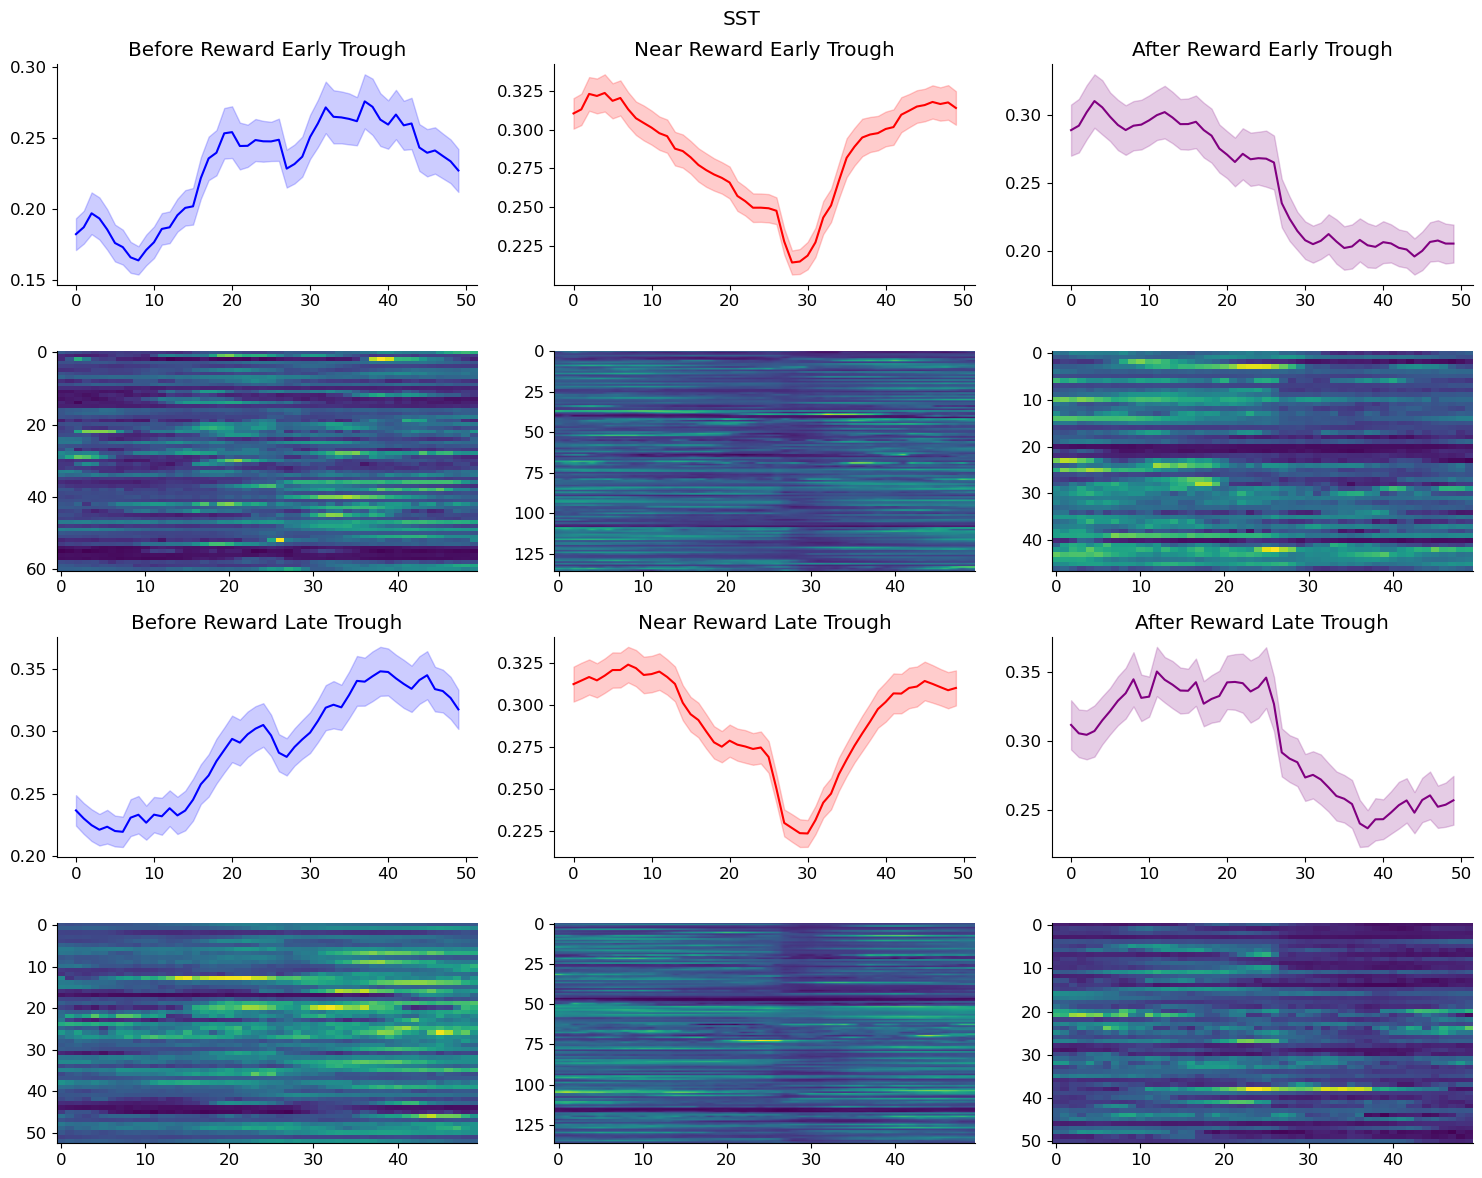

In [32]:
plot_clustered_averages(clusters_dict_labelled_field_type_early_SST_trough, clusters_dict_labelled_field_type_late_SST_trough, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, use_trough=True, plot=True, cell_type="SST")
mean_before_field_array_early_trough_SST, mean_near_field_array_early_trough_SST, mean_after_field_array_early_trough_SST, mean_before_field_array_late_trough_SST, mean_near_field_array_late_trough_SST, mean_after_field_array_late_trough_SST, noisy_field_array_early_trough_SST, noisy_field_array_late_trough_SST = plot_clustered_averages(clusters_dict_labelled_field_type_early_SST_trough, clusters_dict_labelled_field_type_late_SST_trough, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, plot=False)


noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)
noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


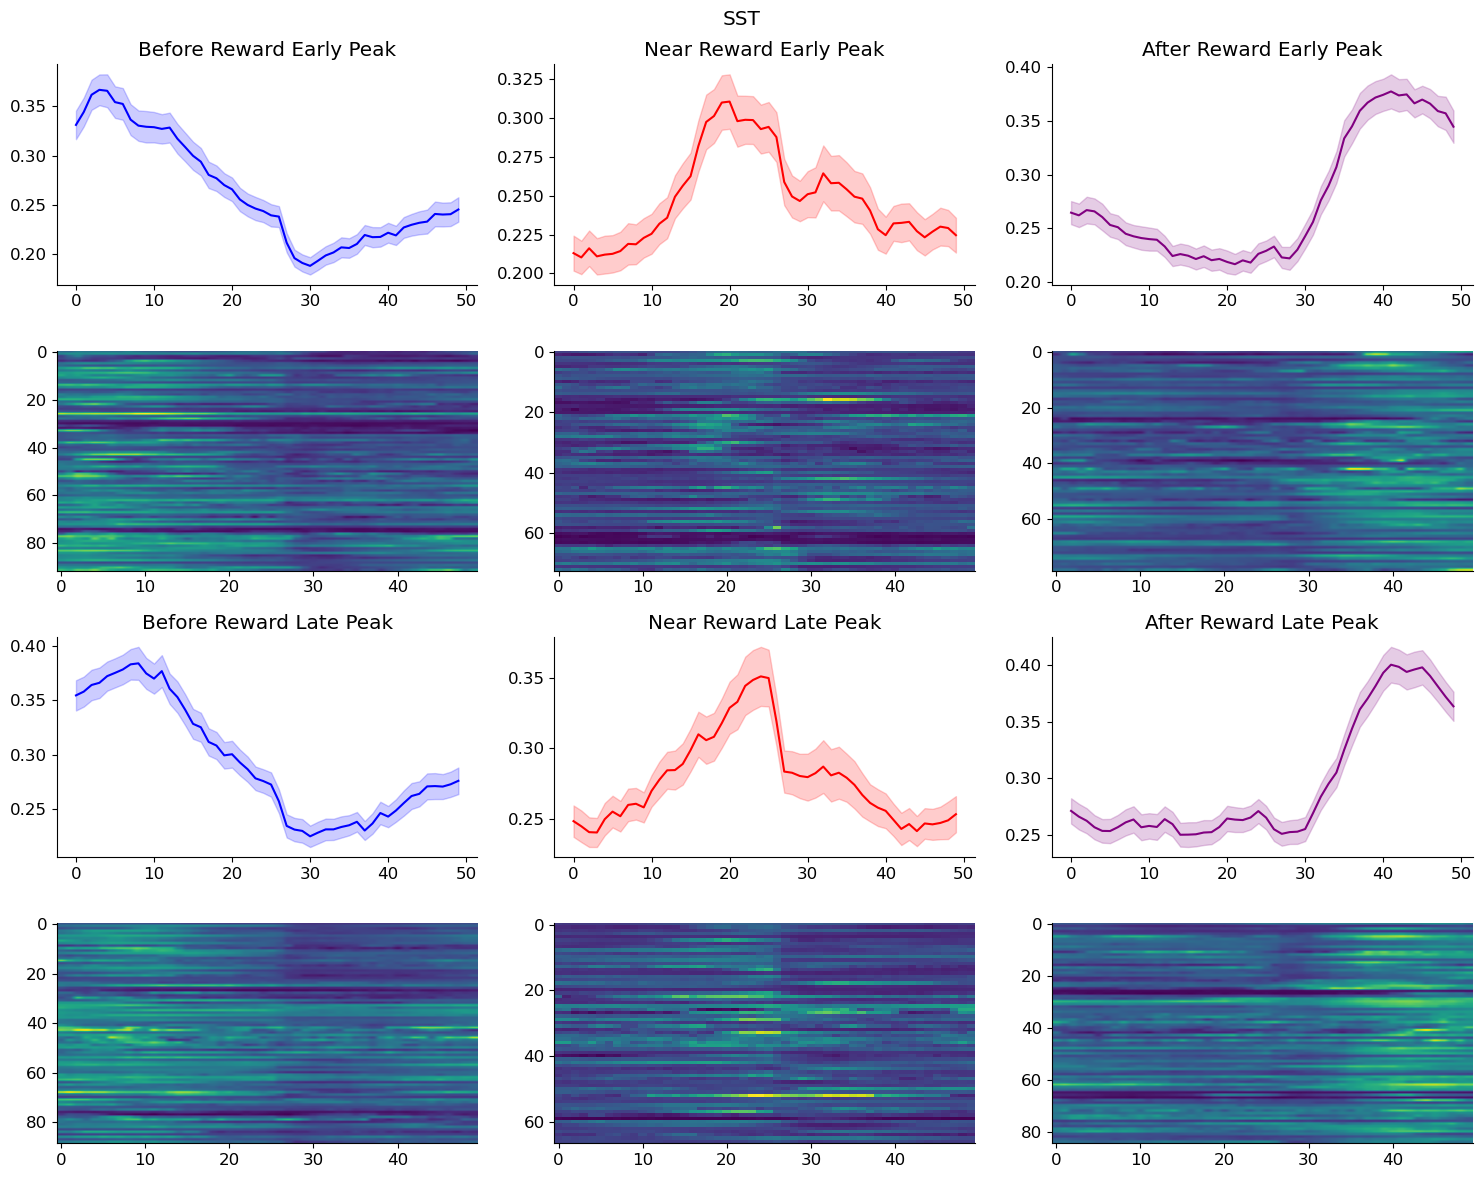

In [33]:
plot_clustered_averages(clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, use_trough=False, plot=True, cell_type="SST")
mean_before_field_array_early_peak_SST, mean_near_field_array_early_peak_SST, mean_after_field_array_early_peak_SST, mean_before_field_array_late_peak_SST, mean_near_field_array_late_peak_SST, mean_after_field_array_late_peak_SST, noisy_field_array_early_peak_SST, noisy_field_array_late_peak_SST = plot_clustered_averages(clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, plot=False)
    

noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)
noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


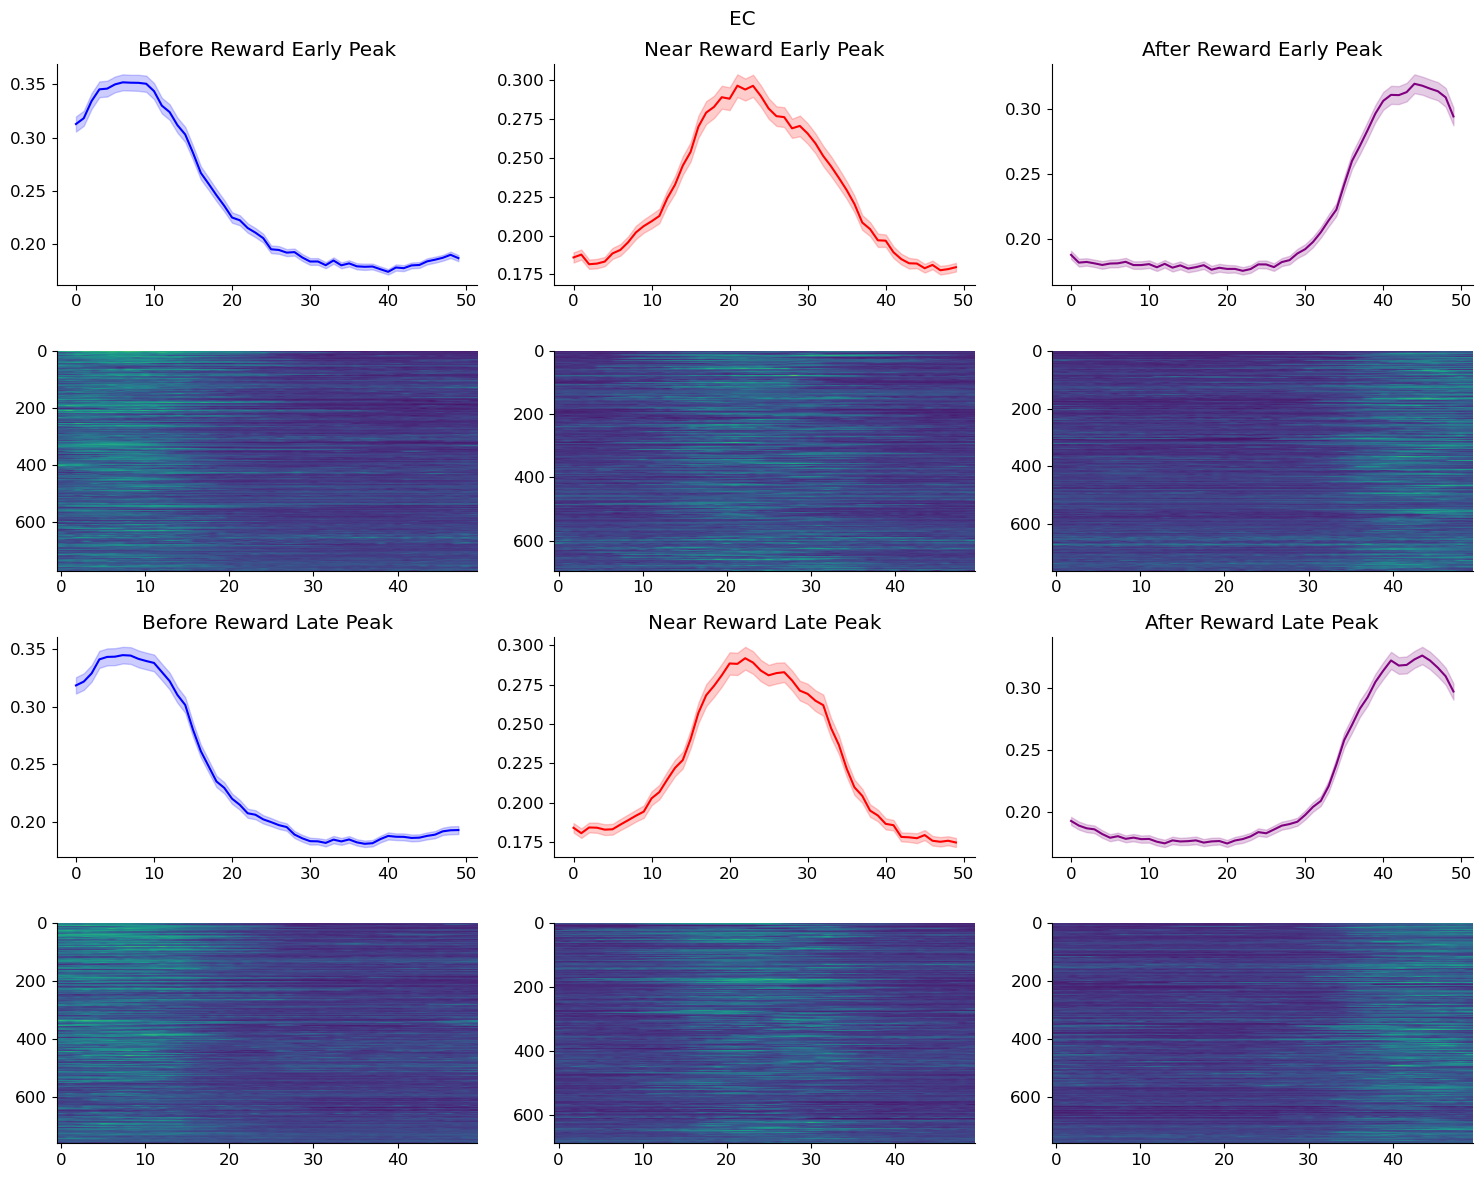

In [34]:
plot_clustered_averages(clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, use_trough=False, plot=True, cell_type="EC")
mean_before_field_array_early_peak_EC, mean_near_field_array_early_peak_EC, mean_after_field_array_early_peak_EC, mean_before_field_array_late_peak_EC, mean_near_field_array_late_peak_EC, mean_after_field_array_late_peak_EC, noisy_field_array_early_peak_EC, noisy_field_array_late_peak_EC = plot_clustered_averages(clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, plot=False)
    

noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)
noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


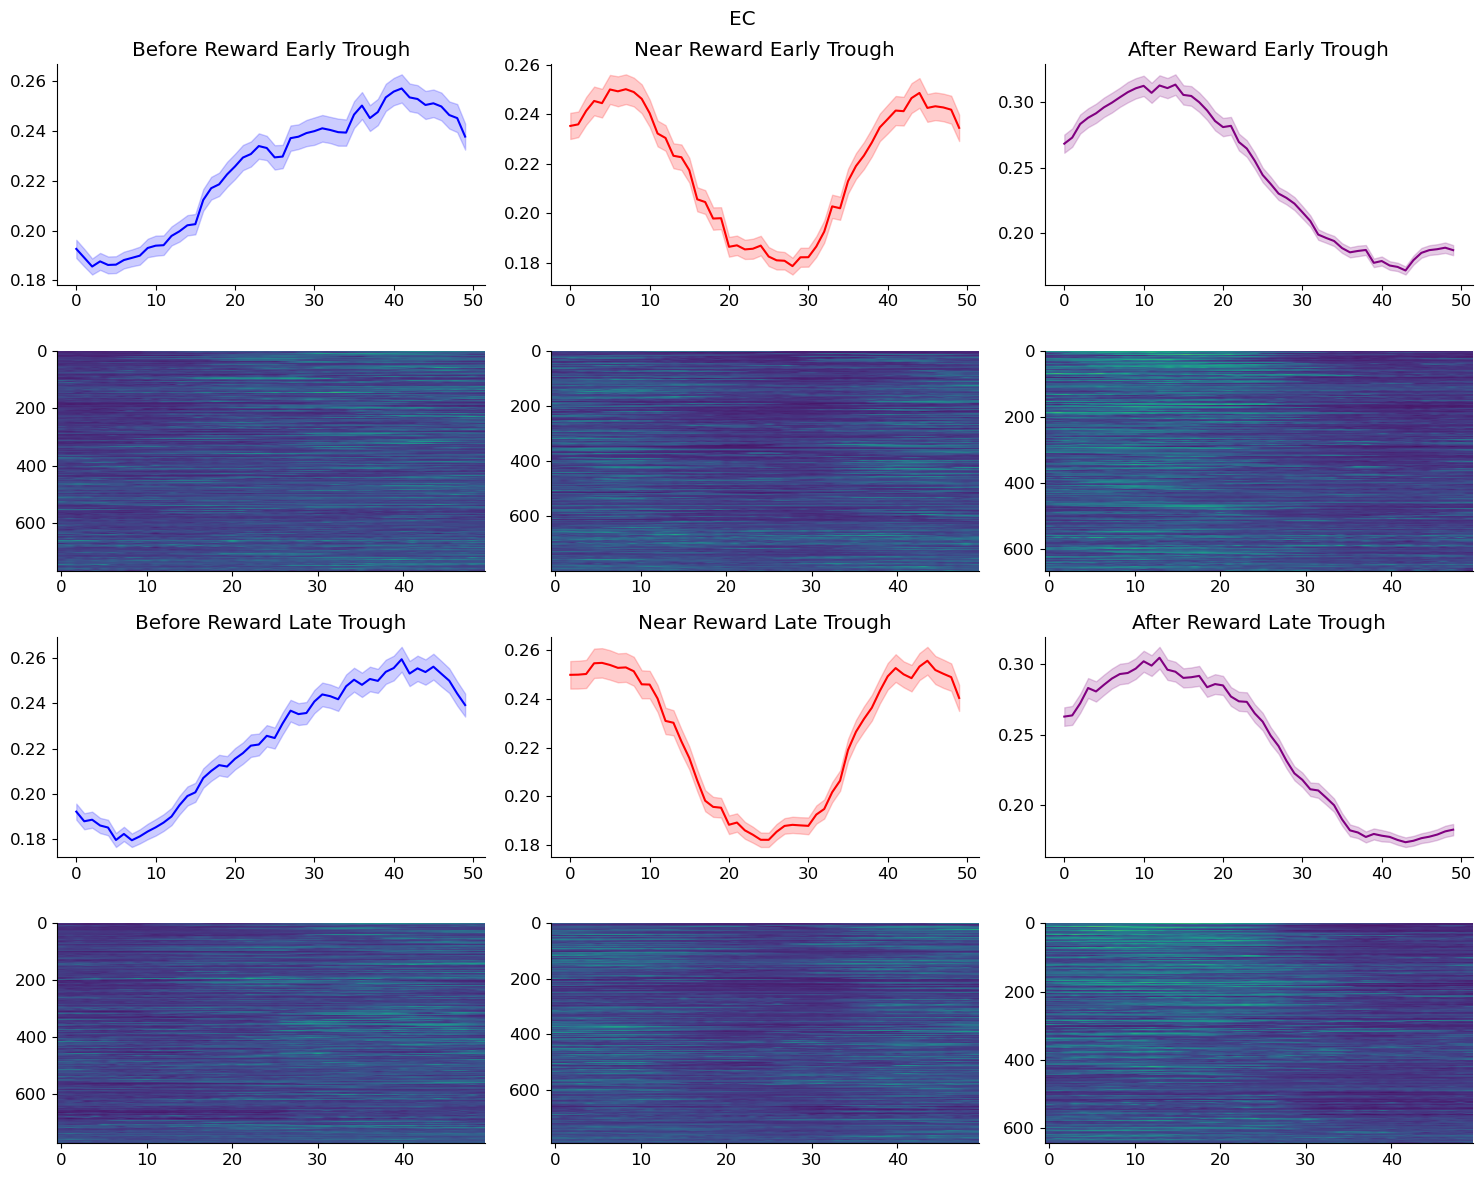

In [35]:
plot_clustered_averages(clusters_dict_labelled_field_type_early_EC_trough, clusters_dict_labelled_field_type_late_EC_trough, clusters_dict_labelled_field_type_early_EC_trough, clusters_dict_labelled_field_type_late_EC_trough, use_trough=True, plot=True, cell_type="EC")
mean_before_field_array_early_trough_EC, mean_near_field_array_early_trough_EC, mean_after_field_array_early_trough_EC, mean_before_field_array_late_trough_EC, mean_near_field_array_late_trough_EC, mean_after_field_array_late_trough_EC, noisy_field_array_early_trough_EC, noisy_field_array_late_trough_EC = plot_clustered_averages(clusters_dict_labelled_field_type_early_EC_trough, clusters_dict_labelled_field_type_late_EC_trough, clusters_dict_labelled_field_type_early_EC_trough, clusters_dict_labelled_field_type_late_EC_trough, plot=False)
   

noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)
noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


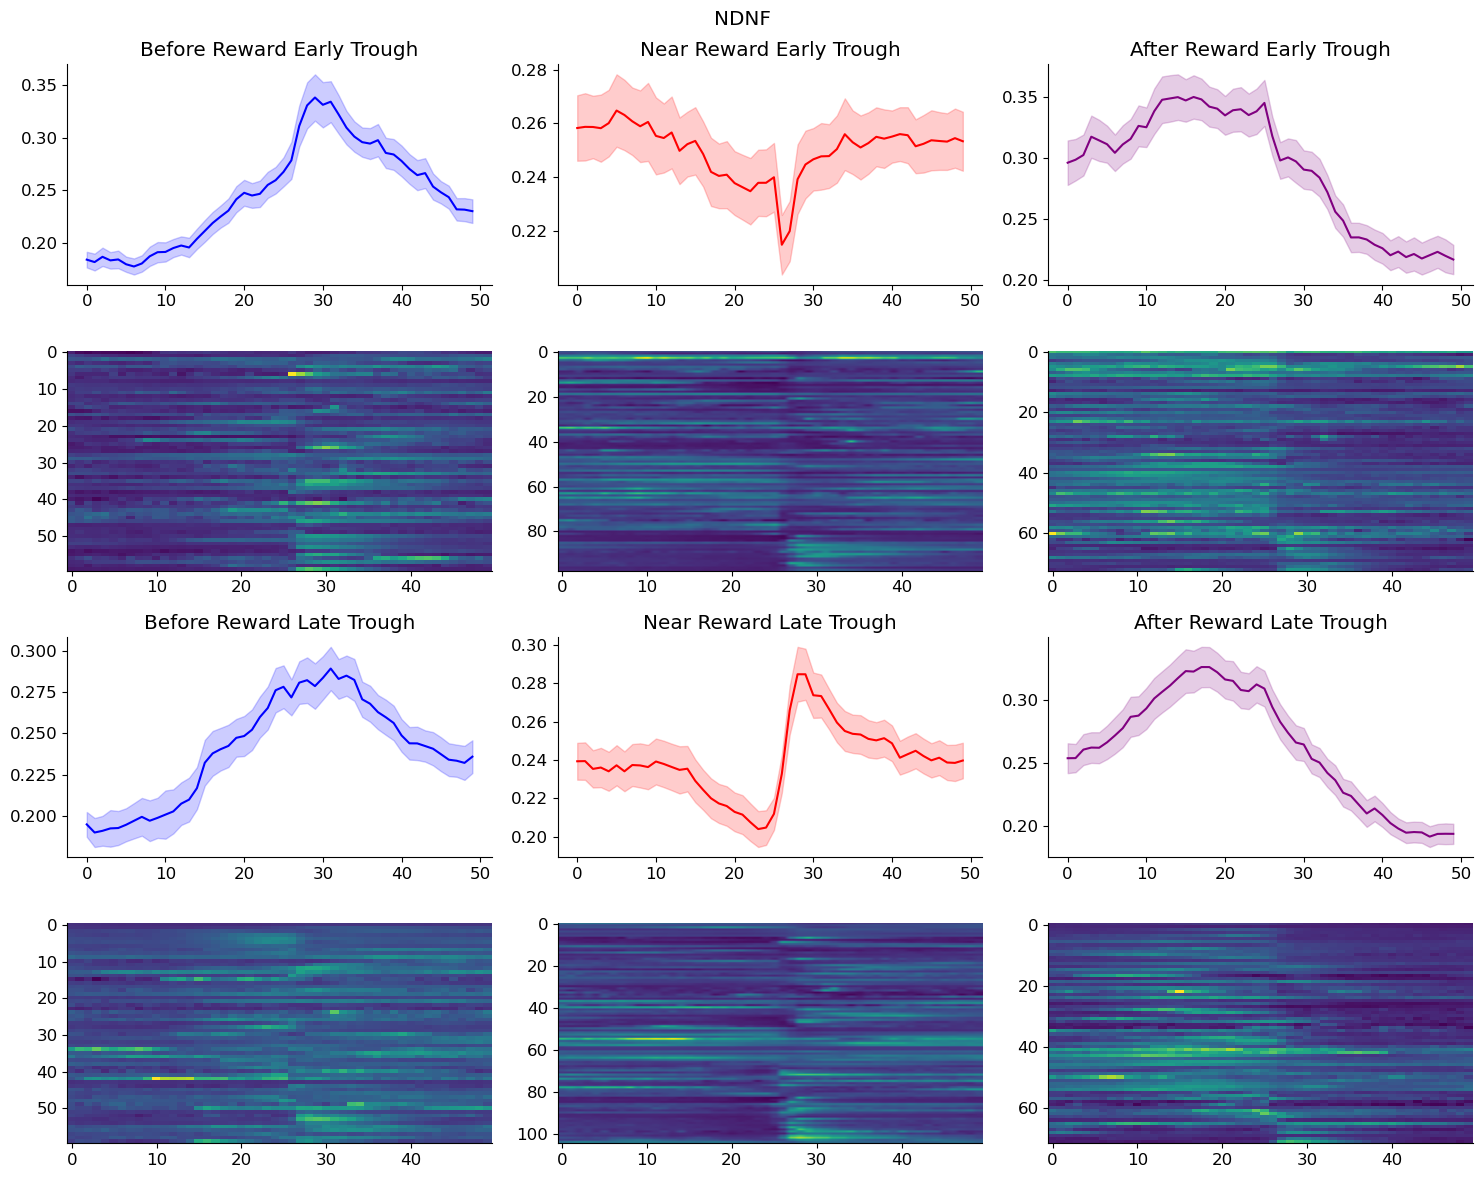

In [36]:
plot_clustered_averages(clusters_dict_labelled_field_type_early_NDNF_trough, clusters_dict_labelled_field_type_late_NDNF_trough, clusters_dict_labelled_field_type_early_NDNF_trough, clusters_dict_labelled_field_type_late_NDNF_trough, use_trough=True, plot=True, cell_type="NDNF")
mean_before_field_array_early_trough_NDNF, mean_near_field_array_early_trough_NDNF, mean_after_field_array_early_trough_NDNF, mean_before_field_array_late_trough_NDNF, mean_near_field_array_late_trough_NDNF, mean_after_field_array_late_trough_NDNF, noisy_field_array_early_trough_NDNF, noisy_field_array_late_trough_NDNF = plot_clustered_averages(clusters_dict_labelled_field_type_early_NDNF_trough, clusters_dict_labelled_field_type_late_NDNF_trough, clusters_dict_labelled_field_type_early_NDNF_trough, clusters_dict_labelled_field_type_late_NDNF_trough, plot=False)
   

noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)
noisy_field_array_early.shape (0,)
noisy_field_array_late.shape (0,)


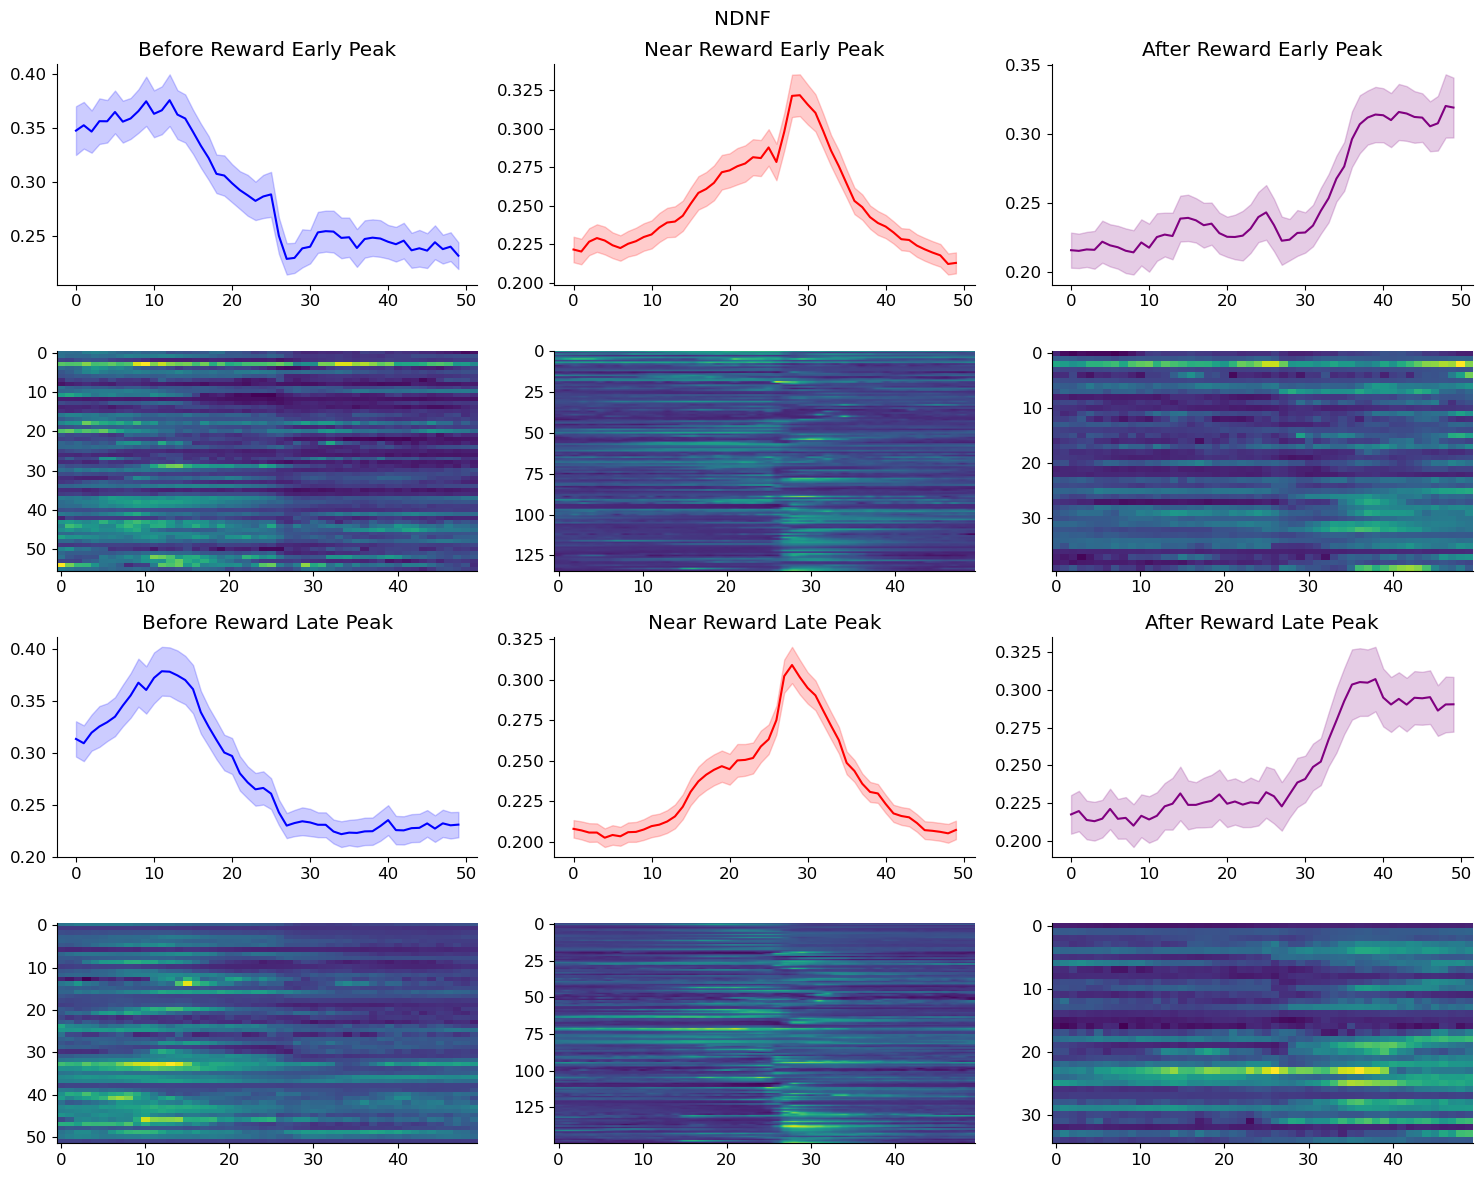

In [37]:
plot_clustered_averages(clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, use_trough=False, plot=True, cell_type="NDNF")
mean_before_field_array_early_peak_NDNF, mean_near_field_array_early_peak_NDNF, mean_after_field_array_early_peak_NDNF, mean_before_field_array_late_peak_NDNF, mean_near_field_array_late_peak_NDNF, mean_after_field_array_late_peak_NDNF, noisy_field_array_early_peak_NDNF, noisy_field_array_late_peak_NDNF = plot_clustered_averages(clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, plot=False)
    

In [108]:
animal_percent_dict_EC_early_peak, percent_lists_EC_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="e")
animal_percent_dict_EC_late_peak, percent_lists_EC_late_peak = get_field_type_percents2(clusters_dict_labelled_field_type_late_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="e")

animal_percent_dict_EC_early_trough, percent_lists_EC_early_trough = get_field_type_percents2(clusters_dict_labelled_field_type_early_EC_trough, cell_EC_model_ranks20_contig_x00, residual_activity_dict_ECe_or_l="l")
animal_percent_dict_EC_late_trough, percent_lists_EC_late_trough = get_field_type_percents2(clusters_dict_labelled_field_type_late_EC_trough, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="l")
# animal_percent_dict_EC_early_peak, percent_lists_EC_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC)


animal_1 cell_1 → total trials: 40 total labeled: 40
animal_1 cell_2 → total trials: 10 total labeled: 10
animal_1 cell_3 → total trials: 20 total labeled: 20
animal_1 cell_4 → total trials: 40 total labeled: 40
animal_1 cell_5 → total trials: 20 total labeled: 20
animal_1 cell_6 → total trials: 35 total labeled: 35
animal_1 cell_7 → total trials: 15 total labeled: 15
animal_1 cell_8 → total trials: 5 total labeled: 5
animal_1 cell_9 → total trials: 50 total labeled: 50
animal_1 cell_10 → total trials: 65 total labeled: 65
animal_1 cell_11 → total trials: 25 total labeled: 25
animal_1 cell_12 → total trials: 35 total labeled: 35
animal_1 cell_13 → total trials: 20 total labeled: 20
animal_1 cell_14 → total trials: 30 total labeled: 30
animal_1 cell_15 → total trials: 30 total labeled: 30
animal_1 cell_16 → total trials: 50 total labeled: 50
animal_1 cell_17 → total trials: 5 total labeled: 5
animal_1 cell_18 → total trials: 10 total labeled: 10
animal_1 cell_19 → total trials: 5 total 

TypeError: get_field_type_percents2() got an unexpected keyword argument 'residual_activity_dict_ECe_or_l'

In [109]:
animal_percent_dict_SST_early_peak, percent_lists_SST_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_SST_peak, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="e")
animal_percent_dict_SST_late_peak, percent_lists_SST_late_peak = get_field_type_percents2(clusters_dict_labelled_field_type_late_SST_peak, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="e")

animal_percent_dict_SST_early_trough, percent_lists_SST_early_trough = get_field_type_percents2(clusters_dict_labelled_field_type_early_SST_trough, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="l")
animal_percent_dict_SST_late_trough, percent_lists_SST_late_trough = get_field_type_percents2(clusters_dict_labelled_field_type_late_SST_trough, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="l")


animal_1 cell_2 → total trials: 15 total labeled: 15
animal_1 cell_3 → total trials: 10 total labeled: 10
animal_1 cell_4 → total trials: 35 total labeled: 35
animal_1 cell_5 → total trials: 10 total labeled: 10
animal_1 cell_6 → total trials: 90 total labeled: 90
animal_2 cell_2 → total trials: 35 total labeled: 35
animal_2 cell_3 → total trials: 10 total labeled: 10
animal_2 cell_4 → total trials: 65 total labeled: 65
animal_2 cell_5 → total trials: 35 total labeled: 35
animal_2 cell_6 → total trials: 115 total labeled: 115
animal_2 cell_7 → total trials: 115 total labeled: 115
animal_2 cell_8 → total trials: 25 total labeled: 25
animal_2 cell_9 → total trials: 60 total labeled: 60
animal_2 cell_10 → total trials: 25 total labeled: 25
animal_2 cell_11 → total trials: 40 total labeled: 40
animal_2 cell_12 → total trials: 25 total labeled: 25
animal_2 cell_13 → total trials: 60 total labeled: 60
animal_2 cell_14 → total trials: 45 total labeled: 45
animal_2 cell_15 → total trials: 30 t

In [111]:
animal_percent_dict_NDNF_early_peak, percent_lists_NDNF_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_NDNF_peak, cell_SST_model_ranks20_contig_x00, fixed_NDNF_new_residual_dict, e_or_l="e")
animal_percent_dict_NDNF_late_peak, percent_lists_NDNF_late_peak = get_field_type_percents2(clusters_dict_labelled_field_type_late_NDNF_peak, cell_SST_model_ranks20_contig_x00, fixed_NDNF_new_residual_dict, e_or_l="e")

animal_percent_dict_NDNF_early_trough, percent_lists_NDNF_early_trough = get_field_type_percents2(clusters_dict_labelled_field_type_early_NDNF_trough, cell_SST_model_ranks20_contig_x00, fixed_NDNF_new_residual_dict, e_or_l="e")
animal_percent_dict_NDNF_late_trough, percent_lists_NDNF_late_trough = get_field_type_percents2(clusters_dict_labelled_field_type_late_NDNF_trough, cell_SST_model_ranks20_contig_x00, fixed_NDNF_new_residual_dict, e_or_l="e")


counts 43 we got problem 130 122
counts 46 we got problem 135 122
counts 52 we got problem 150 128
counts 59 we got problem 140 128


IndexError: list index out of range

In [112]:
percent_of_cells_list_NDNF_early_peak, percent_of_cells_list_NDNF_late_peak, percent_of_cells_list_NDNF_early_trough, percent_of_cells_list_NDNF_late_trough = get_cells_percents(animal_percent_dict_NDNF_early_peak, animal_percent_dict_NDNF_late_peak, animal_percent_dict_NDNF_early_trough, animal_percent_dict_NDNF_late_trough)
percent_of_cells_list_SST_early_peak, percent_of_cells_list_SST_late_peak, percent_of_cells_list_SST_early_trough, percent_of_cells_list_SST_late_trough = get_cells_percents(animal_percent_dict_SST_early_peak, animal_percent_dict_SST_late_peak, animal_percent_dict_SST_early_trough, animal_percent_dict_SST_late_trough)
percent_of_cells_list_EC_early_peak, percent_of_cells_list_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough = get_cells_percents(animal_percent_dict_EC_early_peak, animal_percent_dict_EC_late_peak, animal_percent_dict_EC_early_trough, animal_percent_dict_EC_late_trough)


In [45]:
import numpy as np

def generate_gaussian(length=50, peak_position=25, std=5, amplitude=1.0):
    """
    Generate a Gaussian array of given length, peaking at `peak_position`.

    Parameters:
    - length: total number of bins (default 50)
    - peak_position: where the Gaussian peaks (can be float)
    - std: standard deviation of the Gaussian
    - amplitude: height of the peak

    Returns:
    - 1D numpy array of shape (length,)
    """
    x = np.arange(length)
    gaussian = amplitude * np.exp(-0.5 * ((x - peak_position) / std) ** 2)
    return gaussian


import random

def random_timeseries(initial_value: float, volatility: float, count: int):
    time_series = [initial_value, ]
    for _ in range(count):
        time_series.append(time_series[-1] + initial_value * random.gauss(0, 1) * volatility)
    return time_series



In [50]:
def get_early_vs_late_activity(cell_SST_model_ranks20_contig_x00):

    data_early_list = []
    data_late_list = []

    for animal in cell_SST_model_ranks20_contig_x00[20]:
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            data_early = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["cluster_trial_mean_dict"]["clusters_chosen_3"][0]
            data_early_list.append(data_early)
            data_late = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["cluster_trial_mean_dict"]["clusters_chosen_3"][2]
            data_late_list.append(data_late)

    data_early_array = np.array(data_early_list)
    data_late_array = np.array(data_late_list)
    
    return data_early_array, data_late_array

def min_max_my_data(array_data):
    norm_data = (array_data - np.min(array_data)) / (np.max(array_data) - np.min(array_data))
    return norm_data

def compare_within_subtype(cell_SST_model_ranks20_contig_x00, trial_averaged_cell_array_early_SST_trough, trial_averaged_cell_array_late_SST_trough, full_activity_trial_av_array_SST_trough, residual_activity_dict_SST, cell_type="SST Peak"):
    early_array_SST, late_array_SST = get_early_vs_late_activity(cell_SST_model_ranks20_contig_x00)
   
    fig, axs = plt.subplots(2,3, figsize=(15,8))
    
    
    
    early_array_SST_min_max = min_max_my_data(early_array_SST)
    late_array_SST_min_max = min_max_my_data(late_array_SST)

        
    trial_averaged_cell_array_early_SST_trough_min_max = min_max_my_data(trial_averaged_cell_array_early_SST_trough)
    trial_averaged_cell_array_late_SST_trough_min_max = min_max_my_data(trial_averaged_cell_array_late_SST_trough)
        
    mean_early_array_SST = np.mean(early_array_SST, axis=0)
    sem_early_array_SST = sem(early_array_SST, axis=0)
    mean_late_array_SST = np.mean(late_array_SST, axis=0)
    sem_early_array_SST = sem(late_array_SST, axis=0)
    
#     mean_early_array_SST_min_max = np.mean(early_array_SST_min_max, axis=0)
#     sem_early_array_SST_min_max = sem(early_array_SST_min_max, axis=0)
#     mean_late_array_SST_min_max = np.mean(late_array_SST_min_max, axis=0)
#     sem_late_array_SST_min_max = sem(late_array_SST_min_max, axis=0)
    
    mean_early_array_SST_min_max = min_max_my_data(mean_early_array_SST)
    sem_early_array_SST_min_max = min_max_my_data(sem_early_array_SST)
    mean_late_array_SST_min_max = min_max_my_data(mean_late_array_SST)
    sem_late_array_SST_min_max = min_max_my_data(sem_early_array_SST)

    mean_SST_early_model = np.mean(trial_averaged_cell_array_early_SST_trough, axis=0)
    sem_SST_early_model = sem(trial_averaged_cell_array_early_SST_trough, axis=0)
    mean_SST_late_model = np.mean(trial_averaged_cell_array_late_SST_trough, axis=0)
    sem_SST_late_model = sem(trial_averaged_cell_array_late_SST_trough, axis=0)
    
#     mean_SST_early_model_min_max = np.mean(trial_averaged_cell_array_early_SST_trough_min_max, axis=0)
#     sem_SST_early_model_min_max = sem(trial_averaged_cell_array_early_SST_trough_min_max, axis=0)
#     mean_SST_late_model_min_max = np.mean(trial_averaged_cell_array_late_SST_trough_min_max, axis=0)
#     sem_SST_late_model_min_max = sem(trial_averaged_cell_array_late_SST_trough_min_max, axis=0)
    
    mean_SST_early_model_min_max = min_max_my_data(mean_SST_early_model)
    sem_SST_early_model_min_max = min_max_my_data(sem_SST_early_model)
    mean_SST_late_model_min_max = min_max_my_data(mean_SST_late_model)
    sem_SST_late_model_min_max = min_max_my_data(sem_SST_late_model)


    axs[0,0].plot(mean_early_array_SST, color='cyan', label="Real")
    axs[0,0].fill_between(range(len(mean_early_array_SST)), mean_early_array_SST+sem_early_array_SST, mean_early_array_SST-sem_early_array_SST, alpha=0.2, color='cyan')
    axs[0,0].plot(mean_SST_early_model, label="Model", color='cyan', linestyle="--", linewidth=2)
    axs[0,0].fill_between(range(len(mean_SST_early_model)), mean_SST_early_model+sem_SST_early_model, mean_SST_early_model-sem_SST_early_model, alpha=0.2, color='cyan')
    axs[0,0].set_title(f"{cell_type} Early")
    axs[0,0].legend()

    axs[1,0].plot(mean_late_array_SST, color='b', label="Real")
    axs[1,0].fill_between(range(len(mean_late_array_SST)), mean_late_array_SST+sem_early_array_SST, mean_late_array_SST-sem_early_array_SST, alpha=0.2, color='b')
    axs[1,0].plot(mean_SST_late_model, label="Model", color='b', linestyle="--", linewidth=2)
    axs[1,0].fill_between(range(len(mean_SST_late_model)), mean_SST_late_model+sem_SST_late_model, mean_SST_late_model-sem_SST_late_model, alpha=0.2, color='b')
    axs[1,0].set_title(f"{cell_type} Late")
    axs[1,0].legend()
    
    axs[0,1].plot(mean_early_array_SST, color='cyan', label="Early")
    axs[0,1].fill_between(range(len(mean_early_array_SST)), mean_early_array_SST+sem_early_array_SST, mean_early_array_SST-sem_early_array_SST, alpha=0.2, color='cyan')
    axs[0,1].plot(mean_late_array_SST, color='b', label="Late")
    axs[0,1].fill_between(range(len(mean_late_array_SST)), mean_late_array_SST+sem_early_array_SST, mean_late_array_SST-sem_early_array_SST, alpha=0.2, color='b')
    axs[0,1].set_title(f"{cell_type} Real")
    axs[0,1].legend()

    axs[1,1].plot(mean_SST_early_model, label="Early", color='cyan', linestyle="--", linewidth=2)
    axs[1,1].fill_between(range(len(mean_SST_early_model)), mean_SST_early_model+sem_SST_early_model, mean_SST_early_model-sem_SST_early_model, alpha=0.2, color='cyan')
    axs[1,1].plot(mean_SST_late_model, label="Late", color='b', linestyle="--", linewidth=2)
    axs[1,1].fill_between(range(len(mean_SST_late_model)), mean_SST_late_model+sem_SST_late_model, mean_SST_late_model-sem_SST_late_model, alpha=0.2, color='b')
    axs[1,1].set_title(f"{cell_type} Model")
    axs[1,1].legend()
    
    axs[0,2].plot(mean_early_array_SST_min_max, color='cyan', label="Real")
#     axs[0,2].fill_between(range(len(mean_early_array_SST_min_max)), mean_early_array_SST_min_max+sem_early_array_SST_min_max, mean_early_array_SST_min_max-sem_early_array_SST_min_max, alpha=0.2, color='cyan')
    axs[0,2].plot(mean_SST_early_model_min_max, label="Model", color='cyan', linestyle='--', linewidth=2)
#     axs[0,2].fill_between(range(len(mean_SST_early_model_min_max)), mean_SST_early_model_min_max+sem_SST_early_model_min_max, mean_SST_early_model_min_max-sem_SST_early_model_min_max, alpha=0.2, color='cyan')
    axs[0,2].set_title(f"{cell_type} Early Min Max")
    axs[0,2].legend()
    
    axs[1,2].plot(mean_late_array_SST_min_max, color='b', label="Real")
#     axs[1,2].fill_between(range(len(mean_late_array_SST_min_max)), mean_late_array_SST_min_max+sem_late_array_SST_min_max, mean_late_array_SST_min_max-sem_late_array_SST_min_max, alpha=0.2, color='b')
    axs[1,2].plot(mean_SST_late_model_min_max, label="Model", color='b', linestyle='--', linewidth=2)
#     axs[1,2].fill_between(range(len(mean_SST_late_model_min_max)), mean_SST_late_model_min_max+sem_SST_late_model_min_max, mean_SST_late_model_min_max-sem_SST_late_model_min_max, alpha=0.2, color='b')
    axs[1,2].set_title(f"{cell_type} Late Min Max")
    axs[1,2].legend()
    
    plt.tight_layout()
    plt.show()
    
compare_within_subtype(cell_SST_model_ranks20_contig_x00, trial_averaged_cell_array_early_SST_trough, trial_averaged_cell_array_late_SST_trough, full_activity_trial_av_array_SST_trough, residual_activity_dict_SST, cell_type="SST Peak")
    


NameError: name 'trial_averaged_cell_array_early_SST_trough' is not defined




def reconstruct_activity_from_clusters(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, example_before_field_early, example_near_field_early, example_after_field_early, example_before_field_late, example_near_field_late, example_after_field_late, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, num_cells=73, cell_type="EC Trough", plot=False):
    
    before_percent_array = np.array(percent_lists_EC_early_peak[0])
    sum_before = np.sum(before_percent_array)
    near_percent_array = np.array(percent_lists_EC_early_peak[1])
    sum_near = np.sum(near_percent_array)
    after_percent_array = np.array(percent_lists_EC_early_peak[2])
    sum_after = np.sum(after_percent_array)
    noisy_percent_array = np.array(percent_lists_EC_early_peak[4])
    sum_after = np.sum(after_percent_array)

    before_percent_array_late = np.array(percent_lists_EC_late_peak[0])
    sum_before_late = np.sum(before_percent_array_late)
    near_percent_array_late = np.array(percent_lists_EC_late_peak[1])
    sum_near_late = np.sum(near_percent_array_late)
    after_percent_array_late = np.array(percent_lists_EC_late_peak[2])
    sum_after_late = np.sum(after_percent_array_late)
    noisy_percent_array = np.array(percent_lists_EC_early_peak[4])
    sum_after = np.sum(after_percent_array)
    
#     print(f"before_percent_array {sum_before} before_percent_array_late {sum_before_late}")
#     print(f"near_percent_array {sum_near} before_percent_array_late {sum_near_late}")
#     print(f"before_percent_array {sum_after} before_percent_array_late {sum_after_late}")
#     print(f"overall_early {np.sum([sum_before, sum_near, sum_after])} overall_late {np.sum([sum_before_late, sum_near_late, sum_after_late])}")


    trial_averaged_cell_list_early = []
    trial_averaged_cell_list_late = []

    cell_list_early = []
    cell_list_late = []
    
      ##### if we are looking at overall 
    num_trials_list = []
    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            num_trials_list.append(residual_activity_dict_EC[animal][cell].shape[1])
    
    
    available_trials_before_early = percent_of_cells_list_EC_early_trough[0]*len(num_trials_list)
    available_trials_near_early = percent_of_cells_list_EC_early_trough[1]*len(num_trials_list)
    available_trials_after_early = percent_of_cells_list_EC_early_trough[2]*len(num_trials_list)

    available_trials_before_late = percent_of_cells_list_EC_late_trough[0]*len(num_trials_list)
    available_trials_near_late = percent_of_cells_list_EC_late_trough[1]*len(num_trials_list)
    available_trials_after_late = percent_of_cells_list_EC_late_trough[2]*len(num_trials_list)

    
    
    animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, animal_TCA=False)
    
    flat_list_first = [item for sublist in animal_first_changepoints_list for item in sublist]
    
    print(f"len(flat_list_first) {len(flat_list_first)}")
    print(f"len(num_trials_list) {len(num_trials_list)}")
    
    flat_list_second = [item for sublist in animal_second_changepoints_list for item in sublist]
     
    for i in range(len(num_trials_list)):
        rt_early = np.array(random_timeseries(initial_value=inits, volatility=vol, count=49))
        rt_late = np.array(random_timeseries(initial_value=inits, volatility=vol, count=49))
#         cell_array = np.zeros((50,100))
#         cell_array_late = np.zeros((50,100))

#         cell_array = np.tile(example_[:, np.newaxis], (1,100))
#         cell_array_late = np.tile(example_[:, np.newaxis], (1,100))
            
    
    
        num_trials_early = flat_list_first[i]
        num_trials_late = num_trials_list[i] - flat_list_second[i]

    
        cell_array = np.tile(rt_early[:, np.newaxis], (1,num_trials_early))
        cell_array_late = np.tile(rt_late[:, np.newaxis], (1,num_trials_late))
        
        
    

        # Only assign fields if this cell is allowed to express that field
        if i < int(available_trials_before_early):
            proportion_early_before = (before_percent_array[i]/100)*num_trials_early
            trial_indices_before = np.random.choice(num_trials_early, int(proportion_early_before), replace=False)
            for t in trial_indices_before:
                cell_array[:, t] = example_before_field_early

        if i < int(available_trials_near_early):
            proportion_early_near = (near_percent_array[i]/100)*num_trials_early
            trial_indices_near = np.random.choice(num_trials_early, int(proportion_early_near), replace=False)
            for t in trial_indices_near:
                cell_array[:, t] = example_near_field_early

        if i < int(available_trials_after_early):
            proportion_early_after = (after_percent_array[i]/100)*num_trials_early
            trial_indices_after = np.random.choice(num_trials_early, int(proportion_early_after), replace=False)
            for t in trial_indices_after:
                cell_array[:, t] = example_after_field_early

        if i < int(available_trials_before_late):
            proportion_late_before = (before_percent_array_late[i]/100)*num_trials_late
            trial_indices_before_late = np.random.choice(num_trials_late, int(proportion_late_before), replace=False)
            for t in trial_indices_before_late:
                cell_array_late[:, t] = example_before_field_late

        if i < int(available_trials_near_late):
            proportion_late_near = (near_percent_array_late[i]/100)*num_trials_late
            trial_indices_near_late = np.random.choice(num_trials_late, int(proportion_late_near), replace=False)
            for t in trial_indices_near_late:
                cell_array_late[:, t] = example_near_field_late

        if i < int(available_trials_after_late):
            proportion_late_after = (after_percent_array_late[i]/100)*num_trials_late
            trial_indices_after_late = np.random.choice(num_trials_late, int(proportion_late_after), replace=False)
            for t in trial_indices_after_late:
                cell_array_late[:, t] = example_after_field_late
                
        cell_list_early.append(cell_array)
        cell_list_late.append(cell_array_late)
        trial_averaged_cell_list_early.append(np.mean(cell_array, axis=1))
        trial_averaged_cell_list_late.append(np.mean(cell_array_late, axis=1))


    full_activity_list = []
    full_activity_trial_av_list = []

    for i in range(len(cell_list_early)):
        early_component = cell_list_early[i]
        late_component = cell_list_late[i]

        full_actiivty = np.concatenate([early_component, late_component], axis=1)

        full_activity_list.append(full_actiivty)

        full_activity_trial_av_list.append(np.mean(full_actiivty, axis=1))

    
    full_activity_trial_av_array = np.array(full_activity_trial_av_list)
    
    trial_averaged_cell_array_early = np.array(trial_averaged_cell_list_early)
    
    trial_averaged_cell_array_late = np.array(trial_averaged_cell_list_late)
    
    if plot: 
        fig, axs = plt.subplots(5, 3, figsize=(15,20))
        plt.suptitle(cell_type)


        axs[0,0].plot(example_before_field_early, label="Early")
        axs[0,0].plot(example_before_field_late, label="Late")
        axs[0,0].legend()
        axs[0,0].set_title("Inputs Before Field")
        axs[0,0].set_ylabel("Activity")
        axs[0,0].set_xlabel("Position Bins")
        axs[0,0].legend()


        axs[0,1].plot(example_near_field_early, label="Early")
        axs[0,1].plot(example_near_field_late, label="Late")
        axs[0,1].legend()
        axs[0,1].set_title("Inputs Near Field")
        axs[0,1].set_ylabel("Activity")
        axs[0,1].set_xlabel("Position Bins")
        axs[0,1].legend()


        axs[0,2].plot(example_after_field_early, label="Early")
        axs[0,2].plot(example_after_field_late, label="Late")
        axs[0,2].legend()
        axs[0,2].set_title("Inputs After Field")
        axs[0,2].set_ylabel("Activity")
        axs[0,2].set_xlabel("Position Bins")
        axs[0,2].legend()

        
        axs[1,0].hist(before_percent_array, bins=20)
        axs[1,0].set_title(f"Early Before Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[0]*100:.1f}%")
        axs[1,0].set_ylabel("Number of Cells")
        axs[1,0].set_xlabel("Percent of Trials")

        axs[1,1].hist(near_percent_array, bins=20)
        axs[1,1].set_title(f"Early Near Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[1]*100:.1f}%")
        axs[1,1].set_ylabel("Number of Cells")
        axs[1,1].set_xlabel("Percent of Trials")

        axs[1,2].hist(after_percent_array, bins=20)
        axs[1,2].set_title(f"Early After Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[2]*100:.1f}%")
        axs[1,2].set_ylabel("Number of Cells")
        axs[1,2].set_xlabel("Percent of Trials")

        axs[2,0].hist(before_percent_array_late, bins=20)
#         axs[2,0].set_title(f"Late Before Field Probability \n Percent of Cells={available_trials_before_late:.1f}%")
        axs[2,0].set_title("Late Before Field Probability")
        axs[2,0].set_ylabel("Number of Cells")
        axs[2,0].set_xlabel("Percent of Trials")

        axs[2,1].hist(near_percent_array_late, bins=20)
#         axs[2,1].set_title(f"Late Near Field Probability \n Percent of Cells={available_trials_near_late:.1f}%")
        axs[2,1].set_title("Late Near Field Probability")
        axs[2,1].set_ylabel("Number of Cells")
        axs[2,1].set_xlabel("Percent of Trials")

        axs[2,2].hist(after_percent_array_late, bins=20)
#         axs[2,2].set_title(f"Late After Field Probability \n Percent of Cells={available_trials_after_late:.1f}%")
        axs[2,2].set_title("Late After Field Probability")
        axs[2,2].set_ylabel("Number of Cells")
        axs[2,2].set_xlabel("Percent of Trials")

        axs[4,0].imshow(trial_averaged_cell_array_early, aspect='auto')
        axs[4,0].set_ylabel("Cell ID")
        axs[4,0].set_xlabel("Position Bin")

        means_early = np.mean(trial_averaged_cell_array_early, axis=0)
        sems_early = sem(trial_averaged_cell_array_early, axis=0)
        axs[3,0].plot(means_early, color='orange')
        axs[3,0].fill_between(range(len(means_early)), means_early+sems_early, means_early-sems_early, alpha=0.2, color='orange')
        axs[3,0].set_xlabel("Position Bins")
        axs[3,0].set_ylabel("Activity")
        axs[3,0].set_title("Generative Early Learn")

        axs[4,1].imshow(trial_averaged_cell_array_late, aspect='auto')
        axs[4,1].set_ylabel("Cell ID")
        axs[4,1].set_xlabel("Position Bin")

        means_late = np.mean(trial_averaged_cell_array_late, axis=0)
        sems_late = sem(trial_averaged_cell_array_late, axis=0)
        axs[3,1].plot(means_late, color='r')
        axs[3,1].fill_between(range(len(means_late)), means_late+sems_late, means_late-sems_late, alpha=0.2, color='r')
        axs[3,1].set_xlabel("Position Bins")
        axs[3,1].set_ylabel("Activity")
        axs[3,1].set_title("Generative Late Learn")

        axs[4,2].imshow(full_activity_trial_av_array, aspect='auto')
        axs[4,2].set_ylabel("Cell ID")
        axs[4,2].set_xlabel("Position Bin")


        means_overall= np.mean(full_activity_trial_av_list, axis=0)
        sems_overall= sem(full_activity_trial_av_list, axis=0)
        axs[3,2].plot(means_overall, color='purple')
        axs[3,2].fill_between(range(len(means_overall)), means_overall+sems_overall, means_overall-sems_overall, alpha=0.2, color='purple')
        axs[3,2].set_xlabel("Position Bins")
        axs[3,2].set_ylabel("Activity")
        axs[3,2].set_title("Generative Overall Average")

        plt.tight_layout()
        plt.show()


#         plt.plot(means_early, color='orange', label='Early')
#         plt.fill_between(range(len(means_early)), means_early+sems_early, means_early-sems_early, alpha=0.2, color='orange')
#         plt.plot(means_late, color='r', label="Late")
#         plt.fill_between(range(len(means_late)), means_late+sems_late, means_late-sems_late, alpha=0.2, color='r')
#         plt.plot(means_overall, color='purple', label='Overall')
#         plt.fill_between(range(len(means_overall)), means_overall+sems_overall, means_overall-sems_overall, alpha=0.2, color='purple')
#         plt.ylabel("Activity")
#         plt.xlabel("Position Bins")
#         plt.title(cell_type)
#         plt.legend()
#         plt.show()
        
        
    else:
        return cell_list_early, cell_list_late, full_activity_list, trial_averaged_cell_array_early, trial_averaged_cell_array_late, full_activity_trial_av_array

    
example_before_field = generate_gaussian(length=50, peak_position=10, std=5, amplitude=1.0)
example_near_field = generate_gaussian(length=50, peak_position=25, std=5, amplitude=1.0)
example_after_field = generate_gaussian(length=50, peak_position=40, std=5, amplitude=1.0)


example_before_field_late = generate_gaussian(length=50, peak_position=10, std=2, amplitude=1.0)
example_near_field_late = generate_gaussian(length=50, peak_position=25, std=2, amplitude=1.0)
example_after_field_late = generate_gaussian(length=50, peak_position=40, std=2, amplitude=1.0)

    
reconstruct_activity_from_clusters(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, example_before_field, example_near_field, example_after_field, example_before_field_late, example_near_field_late, example_after_field_late, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits = 0.25, vol=0.001, num_cells=73, cell_type="Example Cell", plot=True)


In [119]:



def reconstruct_activity_from_clusters(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, example_before_field_early, example_near_field_early, example_after_field_early, example_before_field_late, example_near_field_late, example_after_field_late, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, num_cells=73, cell_type="EC Trough", plot=False):
    
    before_percent_array = np.array(percent_lists_EC_early_peak[0])
    sum_before = np.sum(before_percent_array)
    near_percent_array = np.array(percent_lists_EC_early_peak[1])
    sum_near = np.sum(near_percent_array)
    after_percent_array = np.array(percent_lists_EC_early_peak[2])
    sum_after = np.sum(after_percent_array)
    noisy_percent_array = np.array(percent_lists_EC_early_peak[4])
    sum_after = np.sum(after_percent_array)

    before_percent_array_late = np.array(percent_lists_EC_late_peak[0])
    sum_before_late = np.sum(before_percent_array_late)
    near_percent_array_late = np.array(percent_lists_EC_late_peak[1])
    sum_near_late = np.sum(near_percent_array_late)
    after_percent_array_late = np.array(percent_lists_EC_late_peak[2])
    sum_after_late = np.sum(after_percent_array_late)
    noisy_percent_array = np.array(percent_lists_EC_early_peak[4])
    sum_after = np.sum(after_percent_array)
    
#     print(f"before_percent_array {sum_before} before_percent_array_late {sum_before_late}")
#     print(f"near_percent_array {sum_near} before_percent_array_late {sum_near_late}")
#     print(f"before_percent_array {sum_after} before_percent_array_late {sum_after_late}")
#     print(f"overall_early {np.sum([sum_before, sum_near, sum_after])} overall_late {np.sum([sum_before_late, sum_near_late, sum_after_late])}")


    trial_averaged_cell_list_early = []
    trial_averaged_cell_list_late = []

    cell_list_early = []
    cell_list_late = []
    
      ##### if we are looking at overall 
#     num_trials_list = []
#     for animal in residual_activity_dict_EC:
#         for cell in residual_activity_dict_EC[animal]:
#             num_trials_list.append(residual_activity_dict_EC[animal][cell].shape[1])
    
    
    animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, animal_TCA=False)
    
    flat_list_first = [item for sublist in animal_first_changepoints_list for item in sublist]
    flat_list_second = [item for sublist in animal_second_changepoints_list for item in sublist]
    
    stack_num_trials_list = np.vstack([flat_list_first, flat_list_second])

    num_trials_list = np.sum(stack_num_trials_list, axis=0)
    
    
    available_cells_before_early = percent_of_cells_list_EC_early_trough[0]*len(num_trials_list)
    available_cells_near_early = percent_of_cells_list_EC_early_trough[1]*len(num_trials_list)
    available_cells_after_early = percent_of_cells_list_EC_early_trough[2]*len(num_trials_list)

    available_cells_before_late = percent_of_cells_list_EC_late_trough[0]*len(num_trials_list)
    available_cells_near_late = percent_of_cells_list_EC_late_trough[1]*len(num_trials_list)
    available_cells_after_late = percent_of_cells_list_EC_late_trough[2]*len(num_trials_list)

     
    for i in range(len(num_trials_list)):
        rt_early = np.array(random_timeseries(initial_value=inits, volatility=vol, count=49))
        rt_late = np.array(random_timeseries(initial_value=inits, volatility=vol, count=49))
#         cell_array = np.zeros((50,100))
#         cell_array_late = np.zeros((50,100))

#         cell_array = np.tile(example_[:, np.newaxis], (1,100))
#         cell_array_late = np.tile(example_[:, np.newaxis], (1,100))
            
    
    
        num_trials_early = flat_list_first[i]
        num_trials_late = num_trials_list[i] - flat_list_second[i]

    
        cell_array = np.tile(rt_early[:, np.newaxis], (1,num_trials_early))
        cell_array_late = np.tile(rt_late[:, np.newaxis], (1,num_trials_late))
        
        
    

        # Only assign fields if this cell is allowed to express that field
        if i < int(available_cells_before_early):
            proportion_early_before = (before_percent_array[i]/100)*num_trials_early
            trial_indices_before = np.random.choice(num_trials_early, int(proportion_early_before), replace=False)
            for t in trial_indices_before:
                cell_array[:, t] = example_before_field_early

        if i < int(available_cells_near_early):
            proportion_early_near = (near_percent_array[i]/100)*num_trials_early
            trial_indices_near = np.random.choice(num_trials_early, int(proportion_early_near), replace=False)
            for t in trial_indices_near:
                cell_array[:, t] = example_near_field_early

        if i < int(available_cells_after_early):
            proportion_early_after = (after_percent_array[i]/100)*num_trials_early
            trial_indices_after = np.random.choice(num_trials_early, int(proportion_early_after), replace=False)
            for t in trial_indices_after:
                cell_array[:, t] = example_after_field_early

        if i < int(available_cells_before_late):
            proportion_late_before = (before_percent_array_late[i]/100)*num_trials_late
            trial_indices_before_late = np.random.choice(num_trials_late, int(proportion_late_before), replace=False)
            for t in trial_indices_before_late:
                cell_array_late[:, t] = example_before_field_late

        if i < int(available_cells_near_late):
            proportion_late_near = (near_percent_array_late[i]/100)*num_trials_late
            trial_indices_near_late = np.random.choice(num_trials_late, int(proportion_late_near), replace=False)
            for t in trial_indices_near_late:
                cell_array_late[:, t] = example_near_field_late

        if i < int(available_cells_after_late):
            proportion_late_after = (after_percent_array_late[i]/100)*num_trials_late
            trial_indices_after_late = np.random.choice(num_trials_late, int(proportion_late_after), replace=False)
            for t in trial_indices_after_late:
                cell_array_late[:, t] = example_after_field_late
                
        cell_list_early.append(cell_array)
        cell_list_late.append(cell_array_late)
        trial_averaged_cell_list_early.append(np.mean(cell_array, axis=1))
        trial_averaged_cell_list_late.append(np.mean(cell_array_late, axis=1))


    full_activity_list = []
    full_activity_trial_av_list = []

    for i in range(len(cell_list_early)):
        early_component = cell_list_early[i]
        late_component = cell_list_late[i]

        full_actiivty = np.concatenate([early_component, late_component], axis=1)

        full_activity_list.append(full_actiivty)

        full_activity_trial_av_list.append(np.mean(full_actiivty, axis=1))

    
    full_activity_trial_av_array = np.array(full_activity_trial_av_list)
    
    trial_averaged_cell_array_early = np.array(trial_averaged_cell_list_early)
    
    trial_averaged_cell_array_late = np.array(trial_averaged_cell_list_late)
    
    if plot: 
        fig, axs = plt.subplots(5, 3, figsize=(15,20))
        plt.suptitle(cell_type)


        axs[0,0].plot(example_before_field_early, label="Early")
        axs[0,0].plot(example_before_field_late, label="Late")
        axs[0,0].legend()
        axs[0,0].set_title("Inputs Before Field")
        axs[0,0].set_ylabel("Activity")
        axs[0,0].set_xlabel("Position Bins")
        axs[0,0].legend()


        axs[0,1].plot(example_near_field_early, label="Early")
        axs[0,1].plot(example_near_field_late, label="Late")
        axs[0,1].legend()
        axs[0,1].set_title("Inputs Near Field")
        axs[0,1].set_ylabel("Activity")
        axs[0,1].set_xlabel("Position Bins")
        axs[0,1].legend()


        axs[0,2].plot(example_after_field_early, label="Early")
        axs[0,2].plot(example_after_field_late, label="Late")
        axs[0,2].legend()
        axs[0,2].set_title("Inputs After Field")
        axs[0,2].set_ylabel("Activity")
        axs[0,2].set_xlabel("Position Bins")
        axs[0,2].legend()

        
        axs[1,0].hist(before_percent_array, bins=20)
        axs[1,0].set_title(f"Early Before Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[0]*100:.1f}%")
        axs[1,0].set_ylabel("Number of Cells")
        axs[1,0].set_xlabel("Percent of Trials")

        axs[1,1].hist(near_percent_array, bins=20)
        axs[1,1].set_title(f"Early Near Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[1]*100:.1f}%")
        axs[1,1].set_ylabel("Number of Cells")
        axs[1,1].set_xlabel("Percent of Trials")

        axs[1,2].hist(after_percent_array, bins=20)
        axs[1,2].set_title(f"Early After Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[2]*100:.1f}%")
        axs[1,2].set_ylabel("Number of Cells")
        axs[1,2].set_xlabel("Percent of Trials")

        axs[2,0].hist(before_percent_array_late, bins=20)
#         axs[2,0].set_title(f"Late Before Field Probability \n Percent of Cells={available_trials_before_late:.1f}%")
        axs[2,0].set_title("Late Before Field Probability")
        axs[2,0].set_ylabel("Number of Cells")
        axs[2,0].set_xlabel("Percent of Trials")

        axs[2,1].hist(near_percent_array_late, bins=20)
#         axs[2,1].set_title(f"Late Near Field Probability \n Percent of Cells={available_trials_near_late:.1f}%")
        axs[2,1].set_title("Late Near Field Probability")
        axs[2,1].set_ylabel("Number of Cells")
        axs[2,1].set_xlabel("Percent of Trials")

        axs[2,2].hist(after_percent_array_late, bins=20)
#         axs[2,2].set_title(f"Late After Field Probability \n Percent of Cells={available_trials_after_late:.1f}%")
        axs[2,2].set_title("Late After Field Probability")
        axs[2,2].set_ylabel("Number of Cells")
        axs[2,2].set_xlabel("Percent of Trials")

        axs[4,0].imshow(trial_averaged_cell_array_early, aspect='auto')
        axs[4,0].set_ylabel("Cell ID")
        axs[4,0].set_xlabel("Position Bin")

        means_early = np.mean(trial_averaged_cell_array_early, axis=0)
        sems_early = sem(trial_averaged_cell_array_early, axis=0)
        axs[3,0].plot(means_early, color='orange')
        axs[3,0].fill_between(range(len(means_early)), means_early+sems_early, means_early-sems_early, alpha=0.2, color='orange')
        axs[3,0].set_xlabel("Position Bins")
        axs[3,0].set_ylabel("Activity")
        axs[3,0].set_title("Generative Early Learn")

        axs[4,1].imshow(trial_averaged_cell_array_late, aspect='auto')
        axs[4,1].set_ylabel("Cell ID")
        axs[4,1].set_xlabel("Position Bin")

        means_late = np.mean(trial_averaged_cell_array_late, axis=0)
        sems_late = sem(trial_averaged_cell_array_late, axis=0)
        axs[3,1].plot(means_late, color='r')
        axs[3,1].fill_between(range(len(means_late)), means_late+sems_late, means_late-sems_late, alpha=0.2, color='r')
        axs[3,1].set_xlabel("Position Bins")
        axs[3,1].set_ylabel("Activity")
        axs[3,1].set_title("Generative Late Learn")

        axs[4,2].imshow(full_activity_trial_av_array, aspect='auto')
        axs[4,2].set_ylabel("Cell ID")
        axs[4,2].set_xlabel("Position Bin")


        means_overall= np.mean(full_activity_trial_av_list, axis=0)
        sems_overall= sem(full_activity_trial_av_list, axis=0)
        axs[3,2].plot(means_overall, color='purple')
        axs[3,2].fill_between(range(len(means_overall)), means_overall+sems_overall, means_overall-sems_overall, alpha=0.2, color='purple')
        axs[3,2].set_xlabel("Position Bins")
        axs[3,2].set_ylabel("Activity")
        axs[3,2].set_title("Generative Overall Average")

        plt.tight_layout()
        plt.show()


#         plt.plot(means_early, color='orange', label='Early')
#         plt.fill_between(range(len(means_early)), means_early+sems_early, means_early-sems_early, alpha=0.2, color='orange')
#         plt.plot(means_late, color='r', label="Late")
#         plt.fill_between(range(len(means_late)), means_late+sems_late, means_late-sems_late, alpha=0.2, color='r')
#         plt.plot(means_overall, color='purple', label='Overall')
#         plt.fill_between(range(len(means_overall)), means_overall+sems_overall, means_overall-sems_overall, alpha=0.2, color='purple')
#         plt.ylabel("Activity")
#         plt.xlabel("Position Bins")
#         plt.title(cell_type)
#         plt.legend()
#         plt.show()
        
        
    else:
        return cell_list_early, cell_list_late, full_activity_list, trial_averaged_cell_array_early, trial_averaged_cell_array_late, full_activity_trial_av_array

    
example_before_field = generate_gaussian(length=50, peak_position=10, std=5, amplitude=1.0)
example_near_field = generate_gaussian(length=50, peak_position=25, std=5, amplitude=1.0)
example_after_field = generate_gaussian(length=50, peak_position=40, std=5, amplitude=1.0)


example_before_field_late = generate_gaussian(length=50, peak_position=10, std=2, amplitude=1.0)
example_near_field_late = generate_gaussian(length=50, peak_position=25, std=2, amplitude=1.0)
example_after_field_late = generate_gaussian(length=50, peak_position=40, std=2, amplitude=1.0)

    
reconstruct_activity_from_clusters(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, example_before_field, example_near_field, example_after_field, example_before_field_late, example_near_field_late, example_after_field_late, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits = 0.25, vol=0.001, num_cells=73, cell_type="Example Cell", plot=True)


ValueError: Cannot take a larger sample than population when 'replace=False'

In [177]:
def reconstruct_activity_from_clusters2(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, example_before_field_early, example_near_field_early, example_after_field_early, example_before_field_late, example_near_field_late, example_after_field_late, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, cell_type="EC Trough", plot=False):

    num_trials_list = np.zeros(792)
    inits=0.25
    vol=0.01
    num_cells=792

    before_percent_array = np.array(percent_lists_EC_early_peak[0])
    near_percent_array = np.array(percent_lists_EC_early_peak[1])
    after_percent_array = np.array(percent_lists_EC_early_peak[2])

    before_percent_array_late = np.array(percent_lists_EC_late_peak[0])
    near_percent_array_late = np.array(percent_lists_EC_late_peak[1])
    after_percent_array_late = np.array(percent_lists_EC_late_peak[2])
    
    animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, animal_TCA=False)
    
    flat_list_first = [item for sublist in animal_first_changepoints_list for item in sublist]
    flat_list_second = [item for sublist in animal_second_changepoints_list for item in sublist]
    
    stack_num_trials_list = np.vstack([flat_list_first, flat_list_second])

    num_trials_list = np.sum(stack_num_trials_list, axis=0)


    available_cells_before_early = percent_of_cells_list_EC_early_trough[0]*len(num_trials_list)
    available_cells_near_early = percent_of_cells_list_EC_early_trough[1]*len(num_trials_list)
    available_cells_after_early = percent_of_cells_list_EC_early_trough[2]*len(num_trials_list)

    cells_with_before_field_early = np.random.choice(num_cells, int(available_cells_before_early), replace=False)
    cells_with_near_field_early = np.random.choice(num_cells, int(available_cells_near_early), replace=False)
    cells_with_after_field_early = np.random.choice(num_cells, int(available_cells_after_early), replace=False)


    available_cells_before_late = percent_of_cells_list_EC_late_trough[0]*len(num_trials_list)
    available_cells_near_late = percent_of_cells_list_EC_late_trough[1]*len(num_trials_list)
    available_cells_after_late = percent_of_cells_list_EC_late_trough[2]*len(num_trials_list)

    cells_with_before_field_late = np.random.choice(num_cells, int(available_cells_before_late), replace=False)
    cells_with_near_field_late = np.random.choice(num_cells, int(available_cells_near_late), replace=False)
    cells_with_after_field_late = np.random.choice(num_cells, int(available_cells_after_late), replace=False)



    cell_array_early_list = []
    cell_array_late_list = []

    for cell in range(len(num_trials_list)):
        rt_early = np.array(random_timeseries(initial_value=inits, volatility=vol, count=49))
        rt_late = np.array(random_timeseries(initial_value=inits, volatility=vol, count=49))
    #         cell_array = np.tile(example_[:, np.newaxis], (1,100))
    #         cell_array_late = np.tile(example_[:, np.newaxis], (1,100))

    #     cell_array = np.tile(rt_early[:, np.newaxis], (1,num_trials_early))
    #     cell_array_late = np.tile(rt_late[:, np.newaxis], (1,num_trials_late))
    # cell_array = np.tile(example_[:, np.newaxis], (1,100))



        num_trials_early = flat_list_first[cell]
        num_trials_late = num_trials_list[cell] - flat_list_second[cell]

        cell_array = np.zeros((50,num_trials_early))
        cell_array_early_list.append(cell_array)
        cell_array_late = np.zeros((50,num_trials_late))
        cell_array_late_list.append(cell_array_late)


    trial_indices_before_list_early = []
    trial_indices_near_list_early = []
    trial_indices_after_list_early = []

    trial_indices_before_list_late = []
    trial_indices_near_list_late = []
    trial_indices_after_list_late = []

    for cell in range(len(num_trials_list)):
        num_trials_early = flat_list_first[cell]
        num_trials_late = num_trials_list[cell] - flat_list_second[cell]

        available_trials_early = np.arange(num_trials_early)
        remaining_trials_early = available_trials_early.copy()

        available_trials_late = np.arange(num_trials_late)
        remaining_trials_late = available_trials_late.copy()

        if cell in cells_with_before_field_early:
            proportion_early_before = (before_percent_array[cell]/100)*num_trials_early
            trial_indices_before = np.random.choice(available_trials_early, int(proportion_early_before), replace=False)
            trial_indices_before_list_early.append(trial_indices_before)
            remaining_trials_early = np.setdiff1d(available_trials_early, trial_indices_before)
            for t in trial_indices_before:
                cell_array_early_list[cell][:, t] = example_before_field_early


        if cell in cells_with_near_field_early:
            proportion_early_near = (near_percent_array[cell]/100)*num_trials_early
            trial_indices_near = np.random.choice(remaining_trials_early, int(proportion_early_near), replace=False)
            trial_indices_near_list_early.append(trial_indices_near)
            remaining_trials_early = np.setdiff1d(remaining_trials_early, trial_indices_near)
            for t in trial_indices_near:
                cell_array_early_list[cell][:, t] = example_near_field_early

        if cell in cells_with_after_field_early:
            proportion_early_after = (after_percent_array[cell]/100)*num_trials_early
            trial_indices_after = np.random.choice(remaining_trials_early, int(proportion_early_after), replace=False)
            trial_indices_after_list_early.append(trial_indices_after)
            for t in trial_indices_after:
                cell_array_early_list[cell][:, t] = example_after_field_early


        if cell in cells_with_before_field_late:
            proportion_late_before = (before_percent_array_late[cell]/100)*num_trials_late
            trial_indices_before = np.random.choice(available_trials_late, int(proportion_late_before), replace=False)
            trial_indices_before_list_late.append(trial_indices_before)
            remaining_trials_late = np.setdiff1d(available_trials_late, trial_indices_before)
            for t in trial_indices_before:
                cell_array_late_list[cell][:, t] = example_before_field_late


        if cell in cells_with_near_field_late:
            proportion_late_near = (near_percent_array_late[cell]/100)*num_trials_late
            trial_indices_near = np.random.choice(remaining_trials_late, int(proportion_late_near), replace=False)
            trial_indices_near_list_late.append(trial_indices_near)
            remaining_trials_late = np.setdiff1d(remaining_trials_late, trial_indices_near)
            for t in trial_indices_near:
                cell_array_late_list[cell][:, t] = example_near_field_late

        if cell in cells_with_after_field_late:
            proportion_late_after = (after_percent_array_late[cell]/100)*num_trials_late
            trial_indices_after = np.random.choice(remaining_trials_late, int(proportion_late_after), replace=False)
            trial_indices_after_list_late.append(trial_indices_after)
            for t in trial_indices_after:
                cell_array_late_list[cell][:, t] = example_after_field_late


    for i in range(len(cell_list_early)):
        early_component = cell_array_early_list[i]
        late_component = cell_array_late_list[i]

        full_actiivty = np.concatenate([early_component, late_component], axis=1)

        full_activity_list.append(full_actiivty)

        full_activity_trial_av_list.append(np.mean(full_actiivty, axis=1))


        full_activity_trial_av_array = np.array(full_activity_trial_av_list)

        trial_averaged_cell_array_early = np.array(trial_averaged_cell_list_early)

        trial_averaged_cell_array_late = np.array(trial_averaged_cell_list_late)

        if plot: 
            fig, axs = plt.subplots(5, 3, figsize=(15,20))
            plt.suptitle(cell_type)


            axs[0,0].plot(example_before_field_early, label="Early")
            axs[0,0].plot(example_before_field_late, label="Late")
            axs[0,0].legend()
            axs[0,0].set_title("Inputs Before Field")
            axs[0,0].set_ylabel("Activity")
            axs[0,0].set_xlabel("Position Bins")
            axs[0,0].legend()


            axs[0,1].plot(example_near_field_early, label="Early")
            axs[0,1].plot(example_near_field_late, label="Late")
            axs[0,1].legend()
            axs[0,1].set_title("Inputs Near Field")
            axs[0,1].set_ylabel("Activity")
            axs[0,1].set_xlabel("Position Bins")
            axs[0,1].legend()


            axs[0,2].plot(example_after_field_early, label="Early")
            axs[0,2].plot(example_after_field_late, label="Late")
            axs[0,2].legend()
            axs[0,2].set_title("Inputs After Field")
            axs[0,2].set_ylabel("Activity")
            axs[0,2].set_xlabel("Position Bins")
            axs[0,2].legend()


            axs[1,0].hist(before_percent_array, bins=20)
            axs[1,0].set_title(f"Early Before Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[0]*100:.1f}%")
            axs[1,0].set_ylabel("Number of Cells")
            axs[1,0].set_xlabel("Percent of Trials")

            axs[1,1].hist(near_percent_array, bins=20)
            axs[1,1].set_title(f"Early Near Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[1]*100:.1f}%")
            axs[1,1].set_ylabel("Number of Cells")
            axs[1,1].set_xlabel("Percent of Trials")

            axs[1,2].hist(after_percent_array, bins=20)
            axs[1,2].set_title(f"Early After Field Probability \n Percent of Cells={percent_of_cells_list_EC_early_trough[2]*100:.1f}%")
            axs[1,2].set_ylabel("Number of Cells")
            axs[1,2].set_xlabel("Percent of Trials")

            axs[2,0].hist(before_percent_array_late, bins=20)
    #         axs[2,0].set_title(f"Late Before Field Probability \n Percent of Cells={available_trials_before_late:.1f}%")
            axs[2,0].set_title("Late Before Field Probability")
            axs[2,0].set_ylabel("Number of Cells")
            axs[2,0].set_xlabel("Percent of Trials")

            axs[2,1].hist(near_percent_array_late, bins=20)
    #         axs[2,1].set_title(f"Late Near Field Probability \n Percent of Cells={available_trials_near_late:.1f}%")
            axs[2,1].set_title("Late Near Field Probability")
            axs[2,1].set_ylabel("Number of Cells")
            axs[2,1].set_xlabel("Percent of Trials")

            axs[2,2].hist(after_percent_array_late, bins=20)
    #         axs[2,2].set_title(f"Late After Field Probability \n Percent of Cells={available_trials_after_late:.1f}%")
            axs[2,2].set_title("Late After Field Probability")
            axs[2,2].set_ylabel("Number of Cells")
            axs[2,2].set_xlabel("Percent of Trials")

            axs[4,0].imshow(trial_averaged_cell_array_early, aspect='auto')
            axs[4,0].set_ylabel("Cell ID")
            axs[4,0].set_xlabel("Position Bin")

            means_early = np.mean(trial_averaged_cell_array_early, axis=0)
            sems_early = sem(trial_averaged_cell_array_early, axis=0)
            axs[3,0].plot(means_early, color='orange')
            axs[3,0].fill_between(range(len(means_early)), means_early+sems_early, means_early-sems_early, alpha=0.2, color='orange')
            axs[3,0].set_xlabel("Position Bins")
            axs[3,0].set_ylabel("Activity")
            axs[3,0].set_title("Generative Early Learn")

            axs[4,1].imshow(trial_averaged_cell_array_late, aspect='auto')
            axs[4,1].set_ylabel("Cell ID")
            axs[4,1].set_xlabel("Position Bin")

            means_late = np.mean(trial_averaged_cell_array_late, axis=0)
            sems_late = sem(trial_averaged_cell_array_late, axis=0)
            axs[3,1].plot(means_late, color='r')
            axs[3,1].fill_between(range(len(means_late)), means_late+sems_late, means_late-sems_late, alpha=0.2, color='r')
            axs[3,1].set_xlabel("Position Bins")
            axs[3,1].set_ylabel("Activity")
            axs[3,1].set_title("Generative Late Learn")

            axs[4,2].imshow(full_activity_trial_av_array, aspect='auto')
            axs[4,2].set_ylabel("Cell ID")
            axs[4,2].set_xlabel("Position Bin")


            means_overall= np.mean(full_activity_trial_av_list, axis=0)
            sems_overall= sem(full_activity_trial_av_list, axis=0)
            axs[3,2].plot(means_overall, color='purple')
            axs[3,2].fill_between(range(len(means_overall)), means_overall+sems_overall, means_overall-sems_overall, alpha=0.2, color='purple')
            axs[3,2].set_xlabel("Position Bins")
            axs[3,2].set_ylabel("Activity")
            axs[3,2].set_title("Generative Overall Average")

            plt.tight_layout()
            plt.show()  
        else:
            return cell_list_early, cell_list_late, full_activity_list, trial_averaged_cell_array_early, trial_averaged_cell_array_late, full_activity_trial_av_array



# trial_av_early = []
# for i in cell_array_early_list:
#     trial_av_early.append(np.mean(i, axis=1))

# trial_av_early_array = np.array(trial_av_early)

# mean_trial_av_early_array = np.mean(trial_av_early_array, axis=0)
# sem_trial_av_early_array = sem(trial_av_early_array, axis=0)



# for i in range(10):
#     plt.imshow(cell_array_early_list[i], aspect='auto')
#     plt.show()

In [178]:
reconstruct_activity_from_clusters2(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, mean_before_field_array_early_peak_EC, mean_near_field_array_early_peak_EC, mean_after_field_array_early_peak_EC, mean_before_field_array_late_peak_EC, mean_near_field_array_late_peak_EC, mean_after_field_array_late_peak_EC, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, cell_type="EC Peak", plot=True)
cell_list_early_EC_peak, cell_list_late_EC_peak, full_activity_list_EC_peak, trial_averaged_cell_array_early_EC_peak, trial_averaged_cell_array_late_EC_peak, full_activity_trial_av_array_EC_peak = reconstruct_activity_from_clusters2(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, mean_before_field_array_early_peak_EC, mean_near_field_array_early_peak_EC, mean_after_field_array_early_peak_EC, mean_before_field_array_late_peak_EC, mean_near_field_array_late_peak_EC, mean_after_field_array_late_peak_EC, percent_lists_EC_late_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, cell_type="EC Peak", plot=False)
compare_within_subtype(cell_EC_model_ranks20_contig_x00, trial_averaged_cell_array_early_EC_peak, trial_averaged_cell_array_late_EC_peak, full_activity_trial_av_array_EC_peak, residual_activity_dict_EC, cell_type="EC Peak")
 

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
    if cell in cells_with_before_field_late:
        proportion_late_before = (before_percent_array[cell]/100)*num_trials_late
        trial_indices_before = np.random.choice(available_trials_late, int(proportion_late_before), replace=False)
        trial_indices_before_list_late.append(trial_indices_before)
        remaining_trials_late = np.setdiff1d(available_trials_late, trial_indices_before)
        for t in trial_indices_before:
            cell_array_late_list[cell][:, t] = example_before_field
        
            
    if cell in cells_with_near_field_late:
        proportion_late_near = (near_percent_array[cell]/100)*num_trials_late
        trial_indices_near = np.random.choice(remaining_trials_late, int(proportion_late_near), replace=False)
        trial_indices_near_list_late.append(trial_indices_near)
        remaining_trials_late = np.setdiff1d(remaining_trials_late, trial_indices_near)
        for t in trial_indices_near:
            cell_array_late_list[cell][:, t] = example_near_field
            
    if cell in cells_with_after_field_late:
        proportion_late_after = (after_percent_array[cell]/100)*num_trials_late
        trial_indices_after = np.random.choice(remaining_trials_late, int(proportion_late_after), replace=False)
        trial_indices_after_list_late.append(trial_indices_after)
        for t in trial_indices_after:
            cell_array_late_list[cell][:, t] = example_after_field
            


In [165]:
all_assigned_cells = np.unique(
    np.concatenate([
        cells_with_before_field_early,
        cells_with_near_field_early,
        cells_with_after_field_early
    ])
)
all_cells = np.arange(792)  # or whatever num_cells is
unassigned_cells = np.setdiff1d(all_cells, all_assigned_cells)

print(f"Number of unassigned cells: {len(unassigned_cells)}")
print(f"Unassigned cell indices: {unassigned_cells}")


Number of unassigned cells: 32
Unassigned cell indices: [  8  13  23  38  48  60 144 154 168 198 208 210 223 227 355 393 408 471
 495 510 512 555 561 589 639 642 669 690 704 730 787 790]


In [160]:
overlap_count = 0
for cell in range(len(num_trials_list)):
    before = trial_indices_before_list[cell] if cell < len(trial_indices_before_list) else np.array([])
    near = trial_indices_near_list[cell] if cell < len(trial_indices_near_list) else np.array([])
    after = trial_indices_after_list[cell] if cell < len(trial_indices_after_list) else np.array([])

    if (len(np.intersect1d(before, near)) > 0 or 
        len(np.intersect1d(before, after)) > 0 or 
        len(np.intersect1d(near, after)) > 0):
        overlap_count += 1

print(f"{overlap_count} cells had overlapping trial assignments.")


326 cells had overlapping trial assignments.


In [137]:
num_cells=792

cells_with_before_field_early = np.random.choice(num_cells, int(available_cells_before_early), replace=False)
cells_with_near_field_early = np.random.choice(num_cells, int(available_cells_near_early), replace=False)
cells_with_after_field_early = np.random.choice(num_cells, int(available_cells_after_early), replace=False)

# Before ∩ Near
overlap_before_near = np.intersect1d(cells_with_before_field_early, cells_with_near_field_early)

# Before ∩ After
overlap_before_after = np.intersect1d(cells_with_before_field_early, cells_with_after_field_early)

# Near ∩ After
overlap_near_after = np.intersect1d(cells_with_near_field_early, cells_with_after_field_early)

print("Before ∩ Near:", len(overlap_before_near), overlap_before_near)
print("Before ∩ After:", len(overlap_before_after), overlap_before_after)
print("Near ∩ After:", len(overlap_near_after), overlap_near_after)


Before ∩ Near: 345 [  1   3   5   6   7   8   9  10  11  14  15  18  22  23  25  27  28  30
  32  34  36  39  53  59  61  62  66  67  70  71  73  78  79  82  85  87
  90  91  98 100 101 107 109 112 113 114 115 117 118 123 124 129 131 137
 138 140 142 147 148 149 151 153 156 158 159 160 164 165 167 170 174 180
 182 183 184 186 188 189 191 192 196 197 199 200 202 203 207 208 209 214
 216 217 219 220 222 224 226 227 230 236 239 242 243 245 247 248 253 256
 258 259 260 262 263 267 268 271 273 275 278 279 280 283 284 286 290 292
 293 295 300 302 305 307 316 318 320 324 325 329 330 331 332 335 337 338
 346 348 353 356 357 358 364 367 368 369 372 378 383 386 388 390 392 394
 395 396 397 398 399 401 403 404 409 412 413 417 418 421 423 426 429 431
 433 434 437 439 443 445 447 448 450 453 454 455 457 459 462 463 464 465
 468 469 471 472 473 474 476 483 484 485 486 487 489 491 497 498 503 504
 507 514 515 516 520 521 523 525 528 530 534 539 541 542 543 544 548 549
 550 554 555 556 558 559 561 564

(array([274.,  46.,  55.,  24.,  73.,  15.,  18.,   8.,  44.,   9.,   9.,
          6.,  33.,   4.,  21.,  12.,  36.,  19.,  29.,  57.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.]),
 <BarContainer object of 20 artists>)

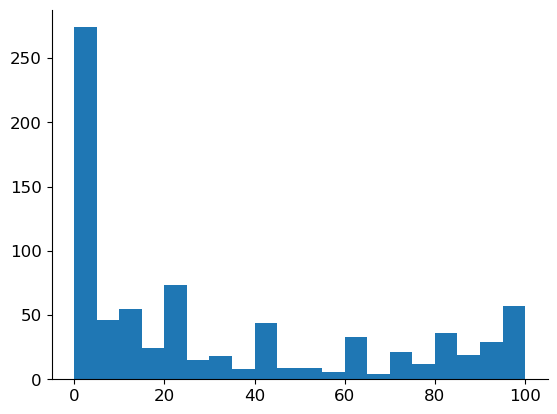

In [130]:
before_percent_array = np.array(percent_lists_EC_early_peak[0])
plt.hist(before_percent_array, bins=20)

len(flat_list_first) 792
len(num_trials_list) 792


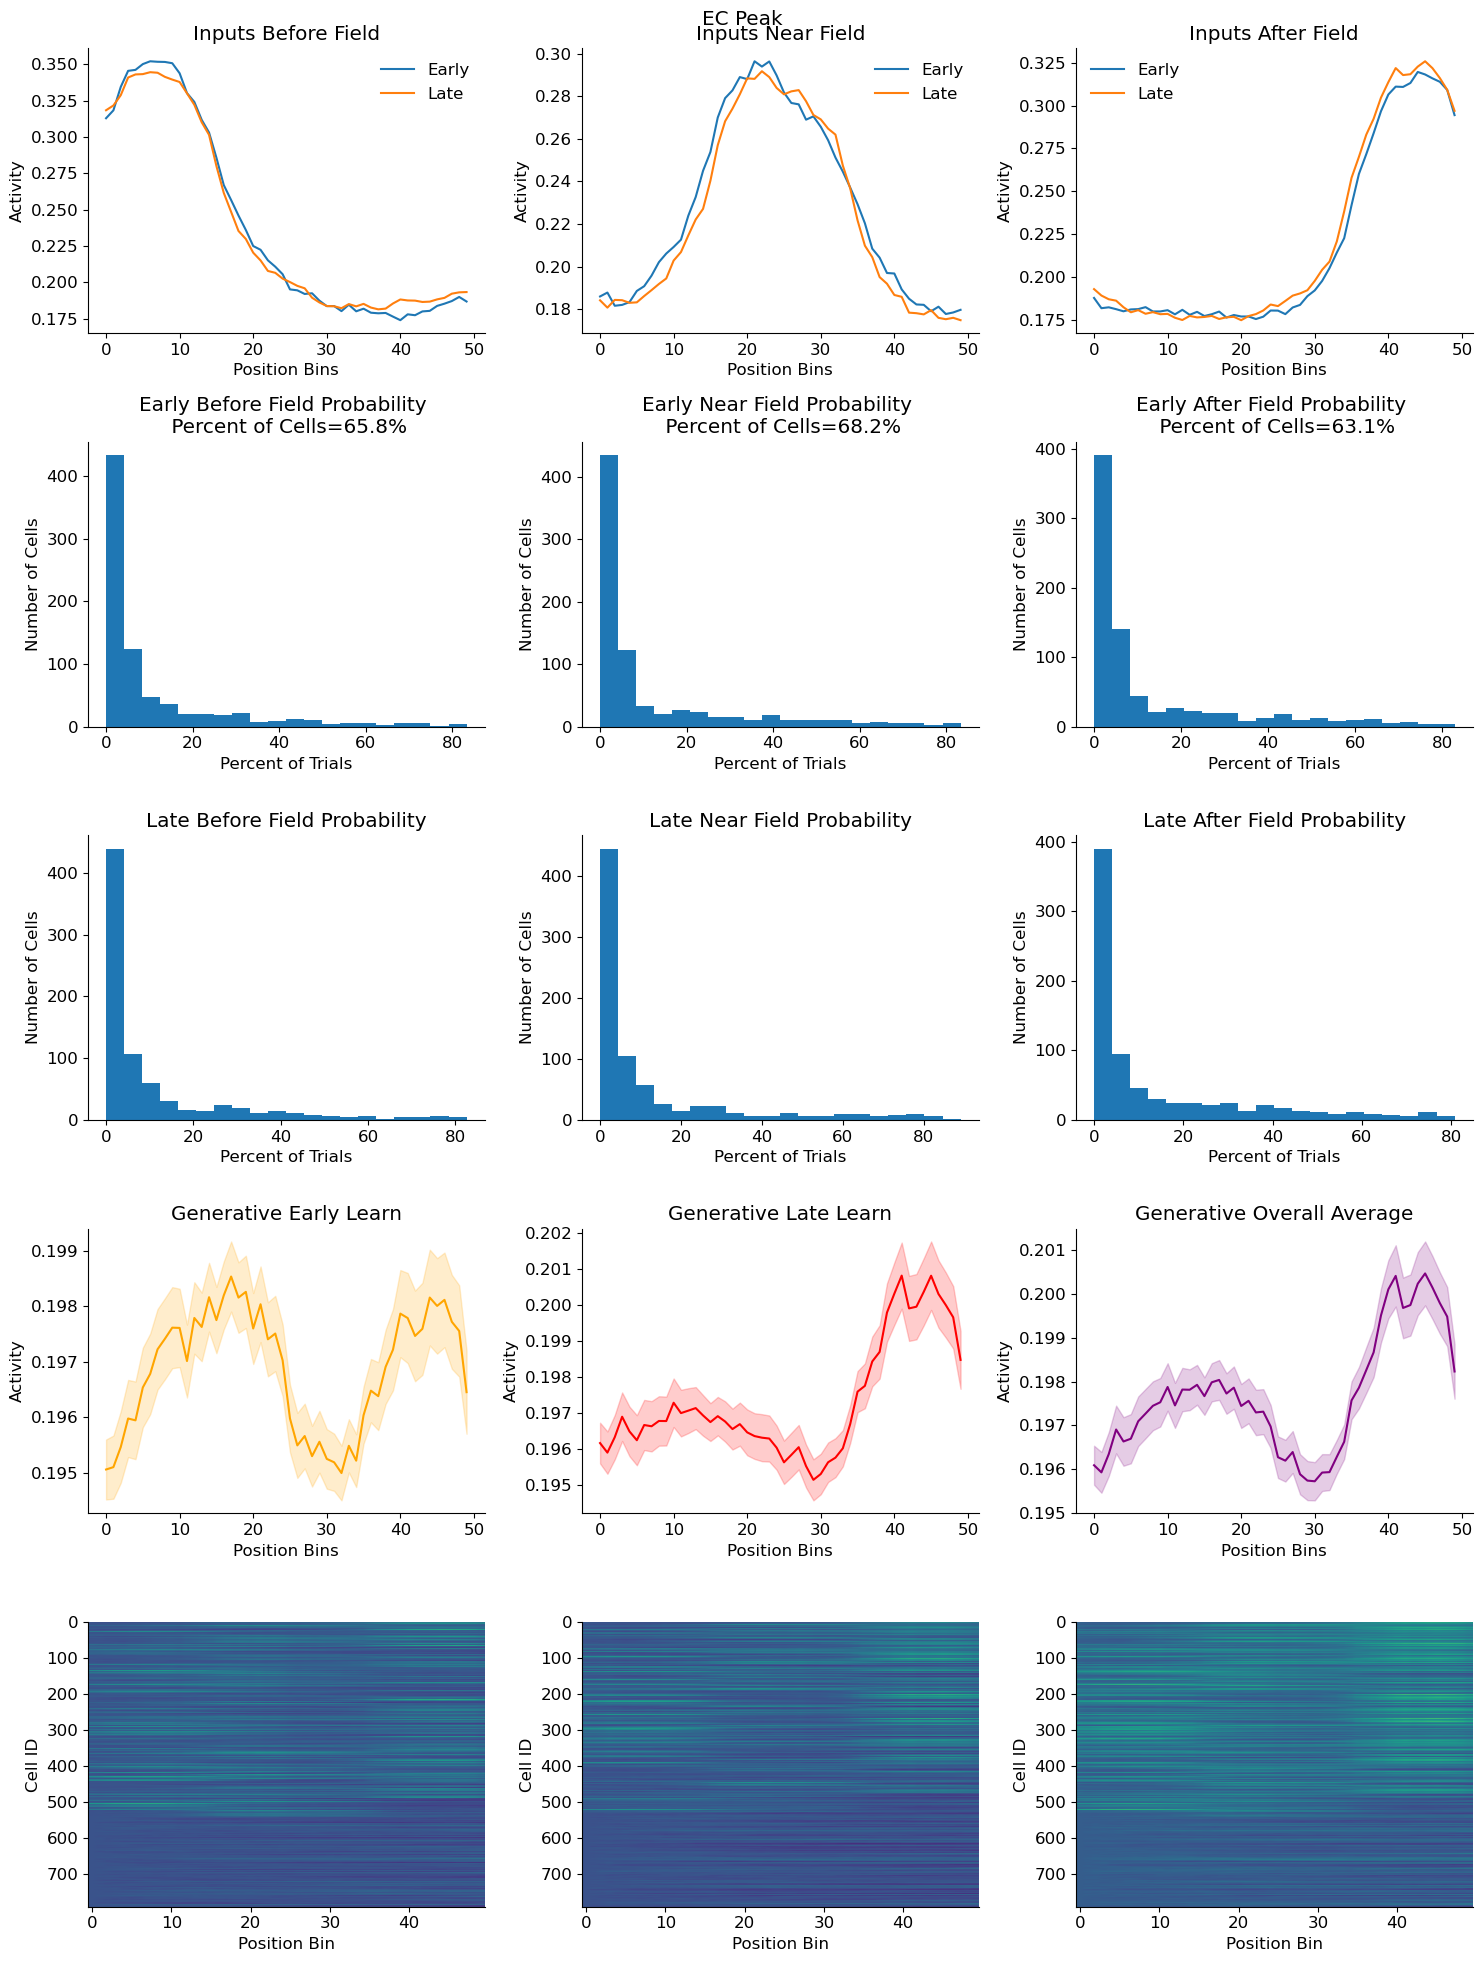

len(flat_list_first) 792
len(num_trials_list) 792


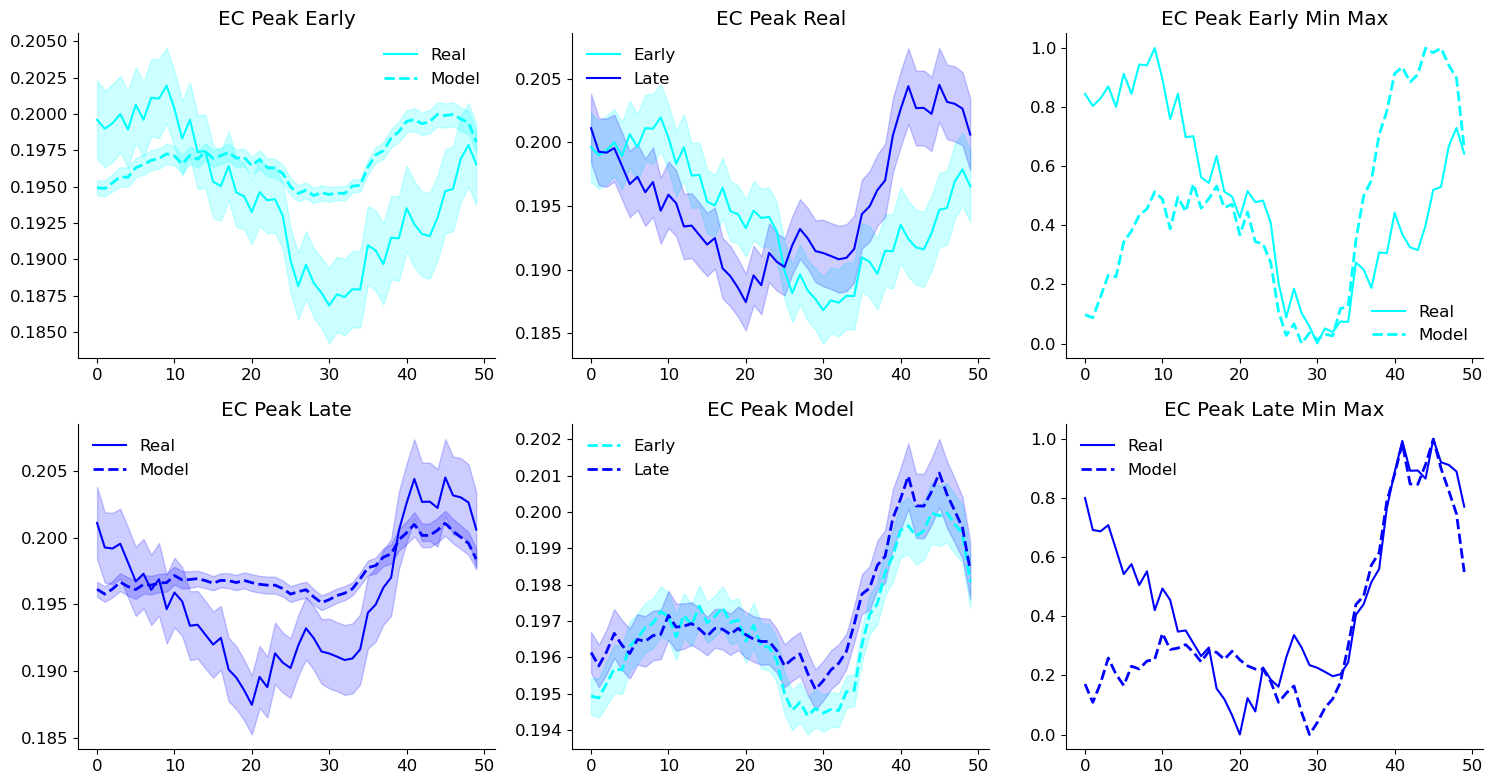

In [52]:
inits=0.19
vol= 0.01

reconstruct_activity_from_clusters(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, mean_before_field_array_early_peak_EC, mean_near_field_array_early_peak_EC, mean_after_field_array_early_peak_EC, mean_before_field_array_late_peak_EC, mean_near_field_array_late_peak_EC, mean_after_field_array_late_peak_EC, percent_lists_EC_early_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, num_cells=73, cell_type="EC Peak", plot=True)
cell_list_early_EC_peak, cell_list_late_EC_peak, full_activity_list_EC_peak, trial_averaged_cell_array_early_EC_peak, trial_averaged_cell_array_late_EC_peak, full_activity_trial_av_array_EC_peak = reconstruct_activity_from_clusters(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, mean_before_field_array_early_peak_EC, mean_near_field_array_early_peak_EC, mean_after_field_array_early_peak_EC, mean_before_field_array_late_peak_EC, mean_near_field_array_late_peak_EC, mean_after_field_array_late_peak_EC, percent_lists_EC_late_peak, percent_lists_EC_late_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, inits, vol, num_cells=73, cell_type="EC Peak", plot=False)
compare_within_subtype(cell_EC_model_ranks20_contig_x00, trial_averaged_cell_array_early_EC_peak, trial_averaged_cell_array_late_EC_peak, full_activity_trial_av_array_EC_peak, residual_activity_dict_EC, cell_type="EC Peak")
 

(5, 75)
(75,)


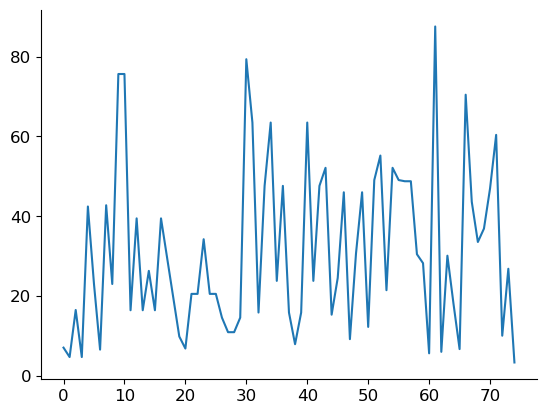

In [76]:
percent_array=np.array(percent_lists_SST_early_trough)
print(percent_array.shape)
       
sums = np.sum(percent_array, axis=0)
print(sums.shape)
plt.plot(sums)
plt.show()

len(flat_list_first) 75
len(num_trials_list) 75


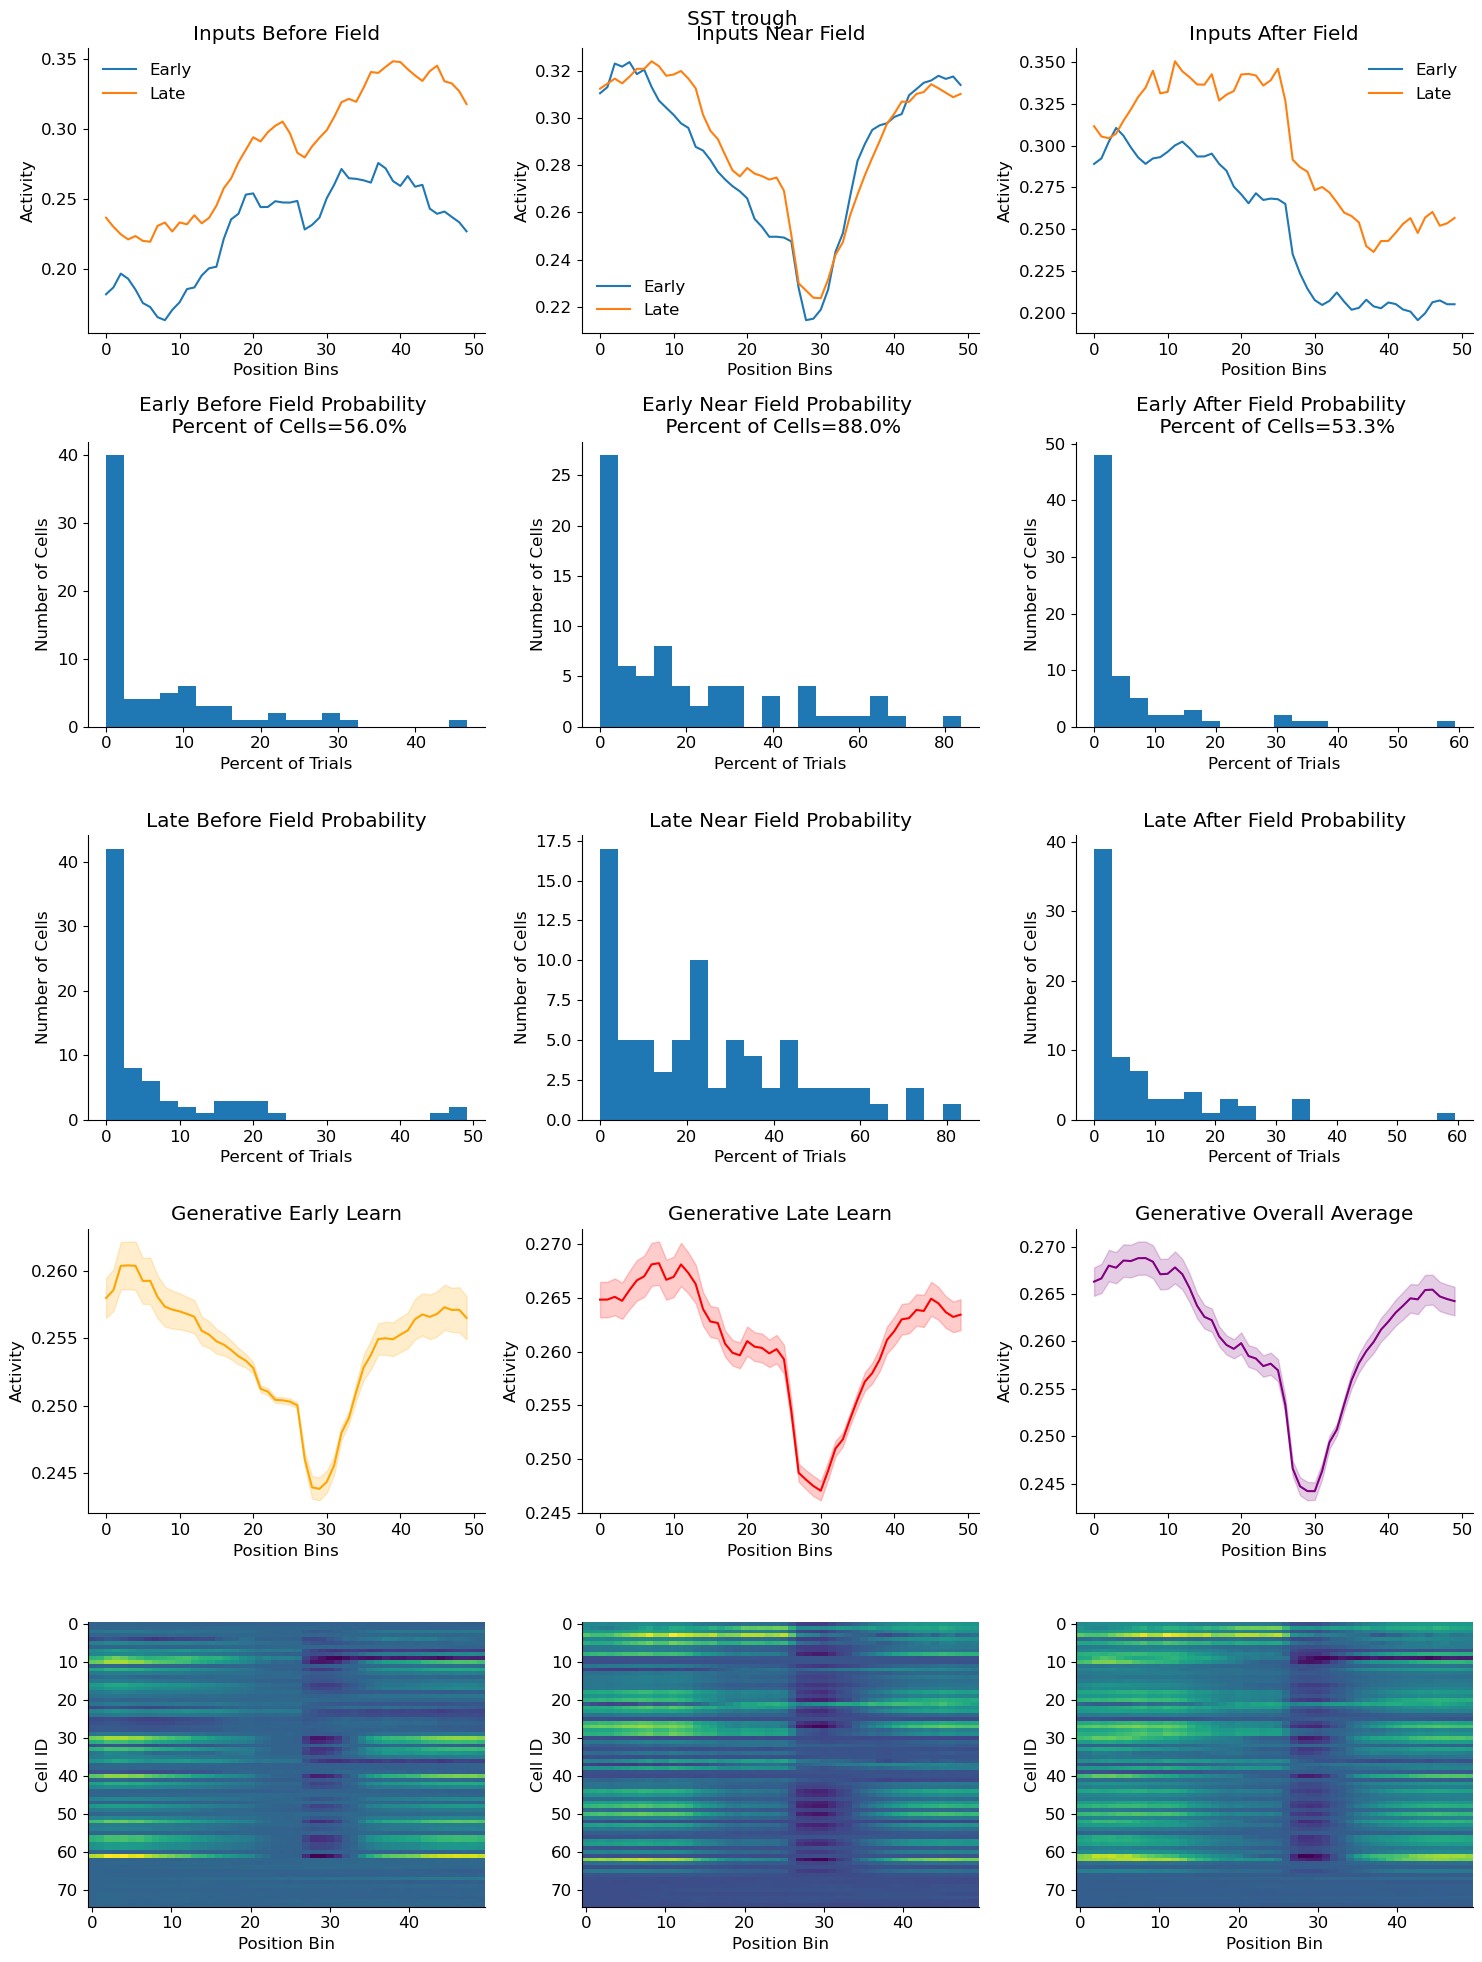

len(flat_list_first) 75
len(num_trials_list) 75


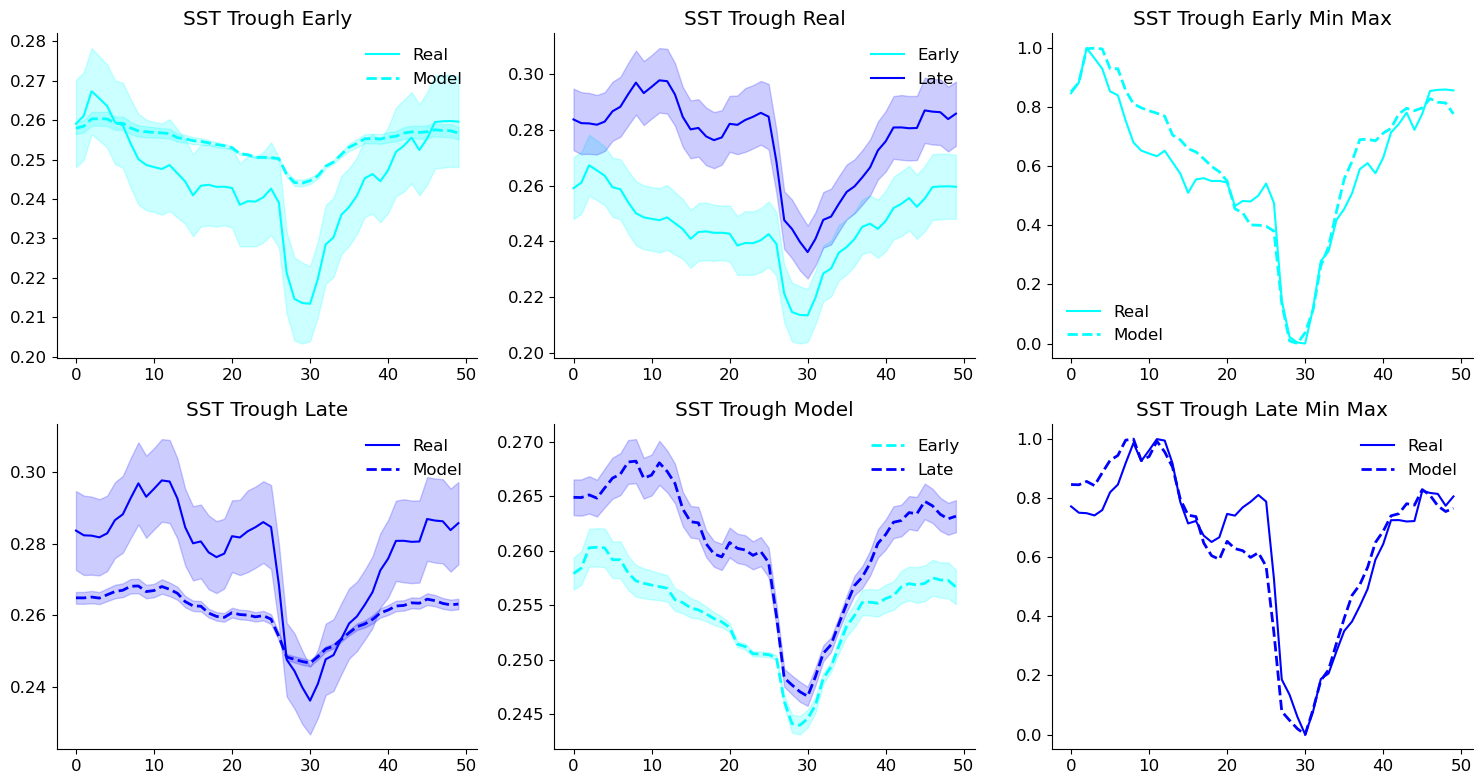

In [69]:
inits=0.25
vol= 0.001

reconstruct_activity_from_clusters(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, mean_before_field_array_early_trough_SST, mean_near_field_array_early_trough_SST, mean_after_field_array_early_trough_SST, mean_before_field_array_late_trough_SST, mean_near_field_array_late_trough_SST, mean_after_field_array_late_trough_SST, percent_lists_SST_early_trough, percent_lists_SST_late_trough, percent_of_cells_list_SST_early_trough, percent_of_cells_list_SST_late_trough, inits, vol, num_cells=73, cell_type="SST trough", plot=True)
model_cell_list_SST_trough_early, model_cell_list_SST_trough_late, full_activity_list_SST_trough, trial_averaged_cell_array_early_SST_trough, trial_averaged_cell_array_late_SST_trough, full_activity_trial_av_array_SST_trough = reconstruct_activity_from_clusters(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, mean_before_field_array_early_trough_SST, mean_near_field_array_early_trough_SST, mean_after_field_array_early_trough_SST, mean_before_field_array_late_trough_SST, mean_near_field_array_late_trough_SST, mean_after_field_array_late_trough_SST, percent_lists_SST_early_trough, percent_lists_SST_late_trough, percent_of_cells_list_SST_early_trough, percent_of_cells_list_SST_late_trough, inits, vol, num_cells=73, cell_type="SST Trough", plot=False)
compare_within_subtype(cell_SST_model_ranks20_contig_x00, trial_averaged_cell_array_early_SST_trough, trial_averaged_cell_array_late_SST_trough, full_activity_trial_av_array_SST_trough, residual_activity_dict_SST, cell_type="SST Trough")
    


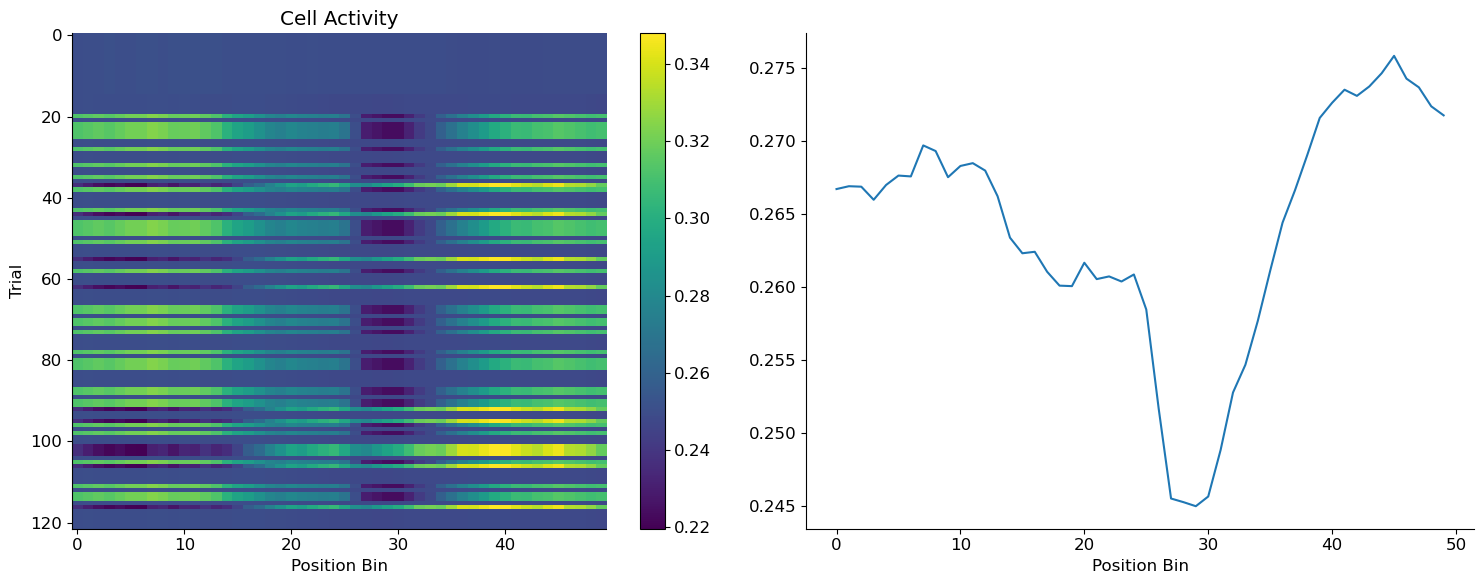

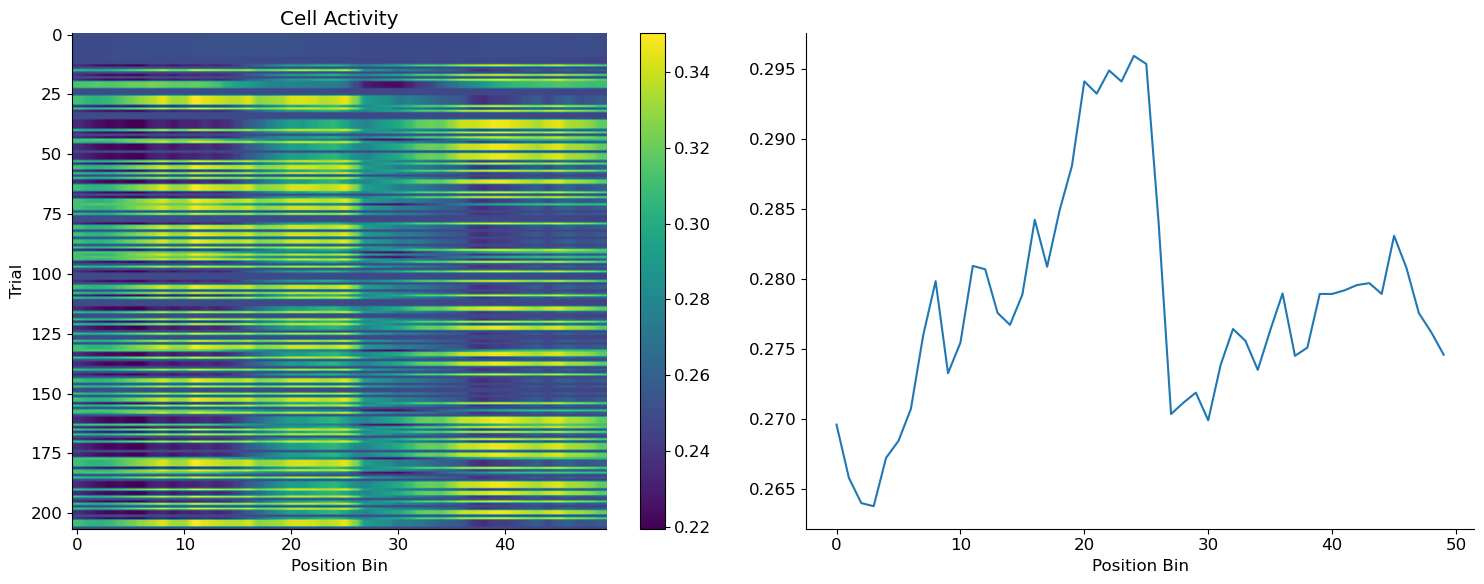

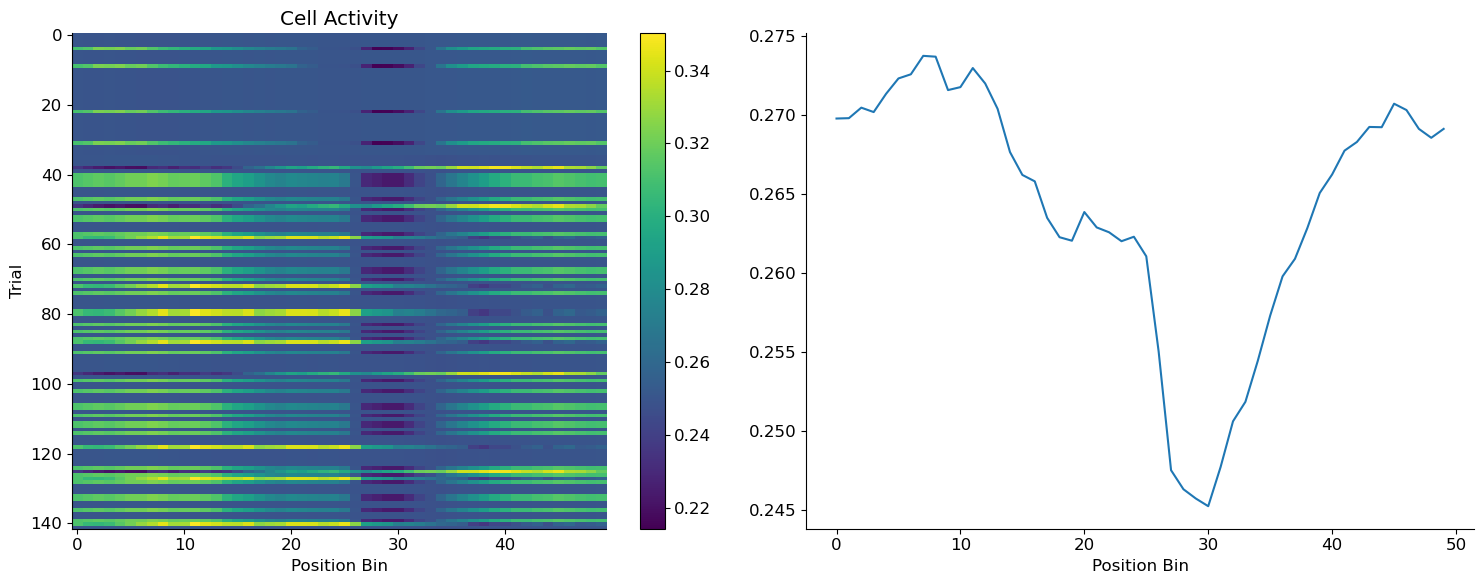

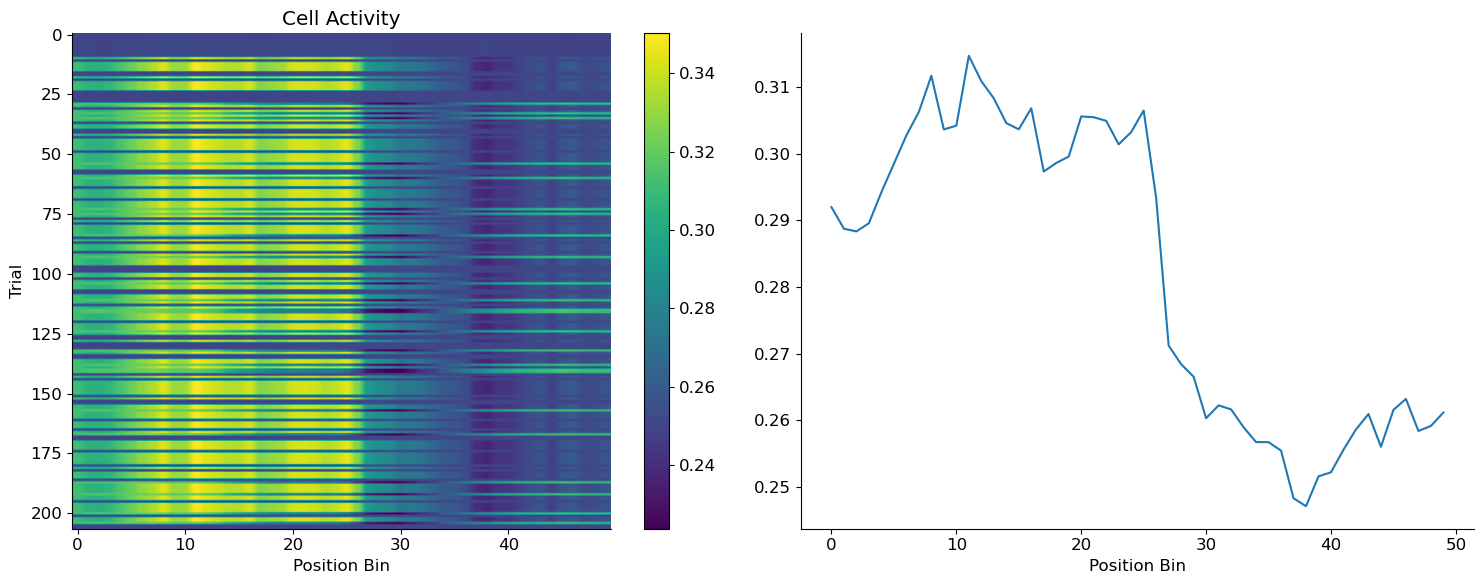

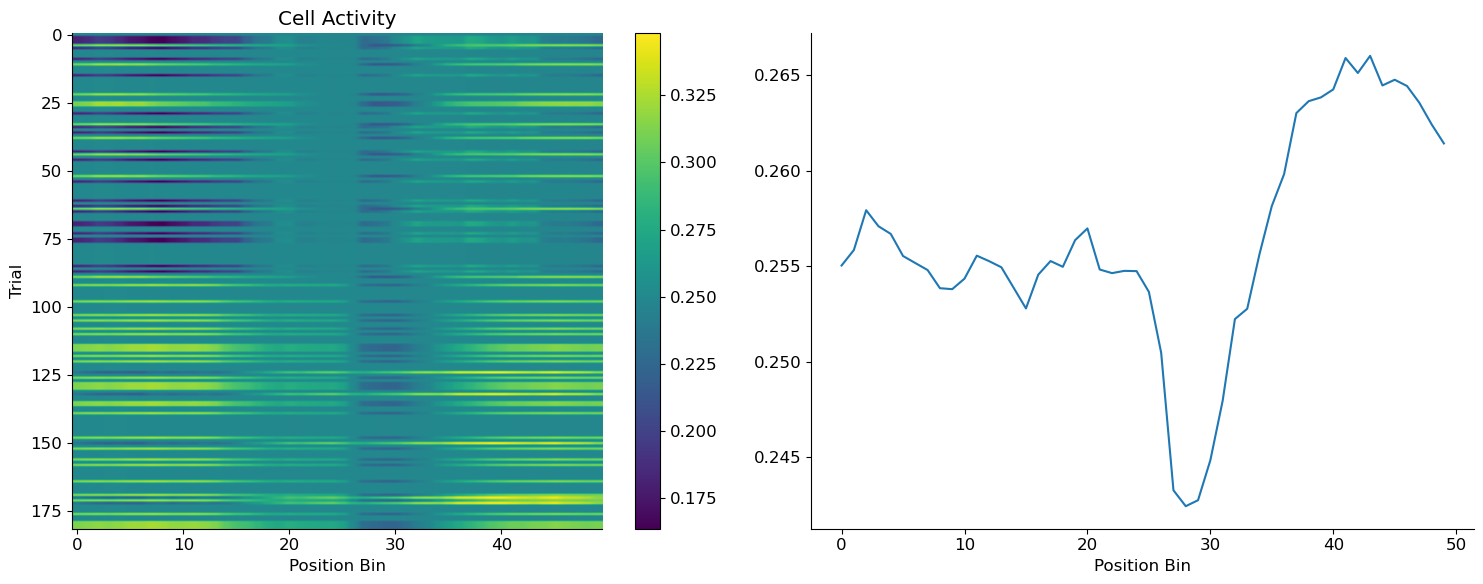

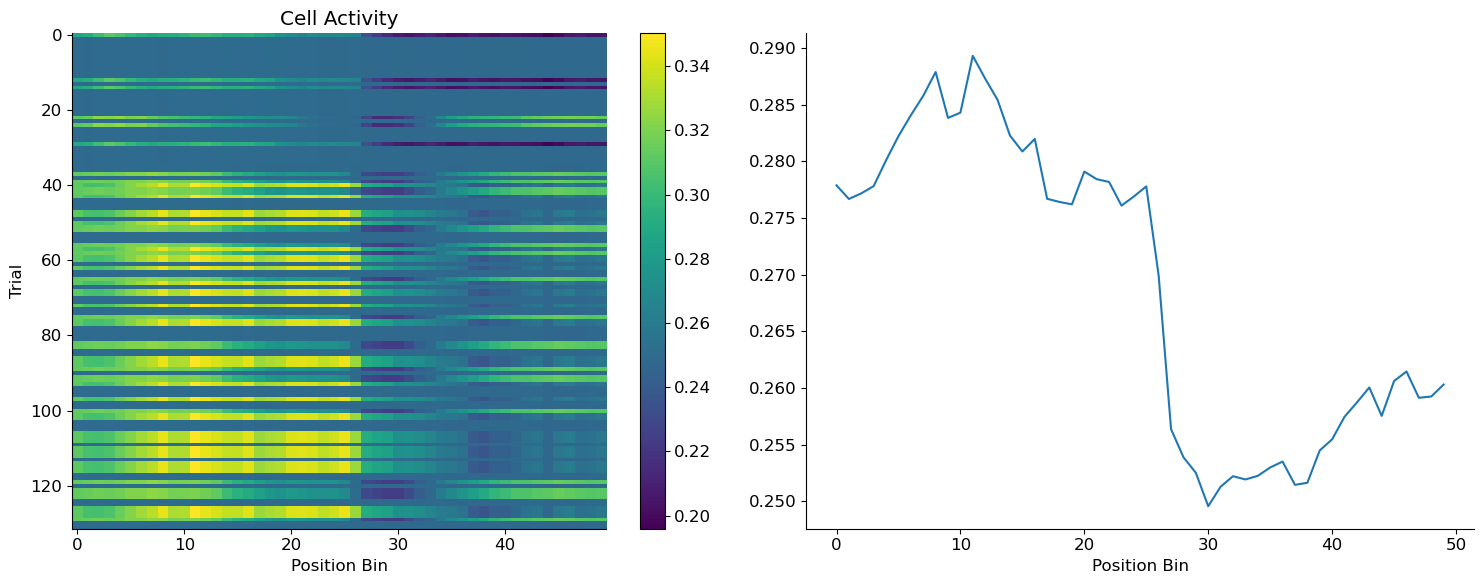

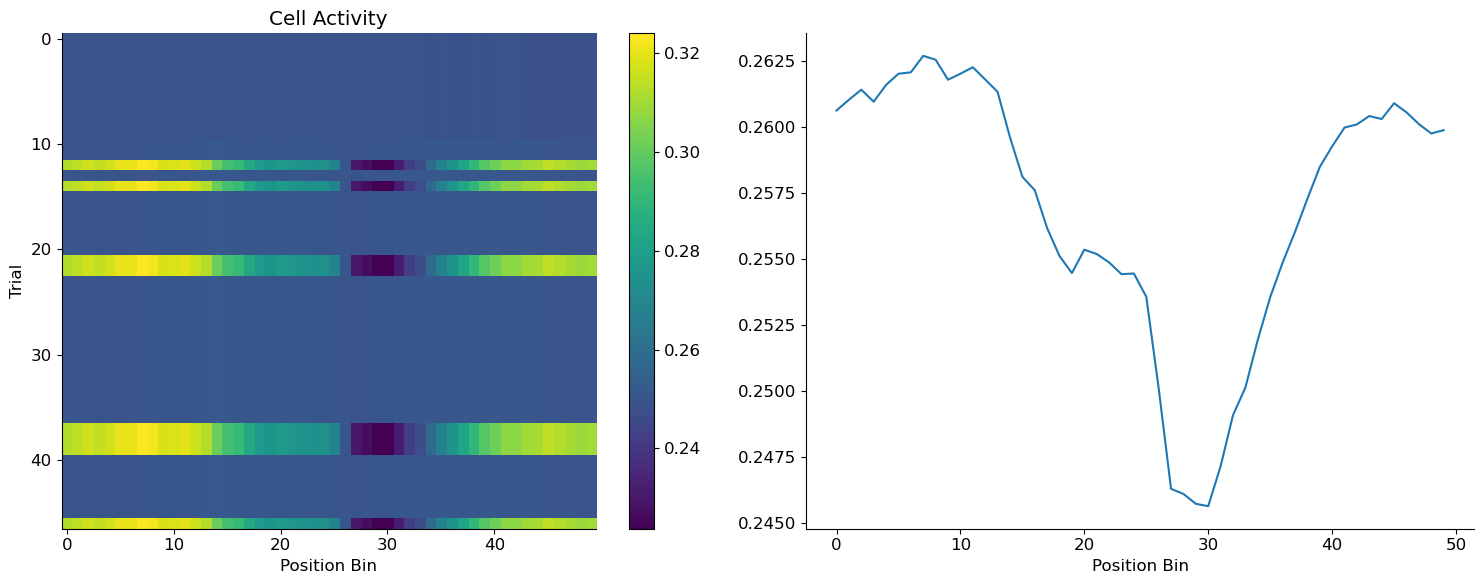

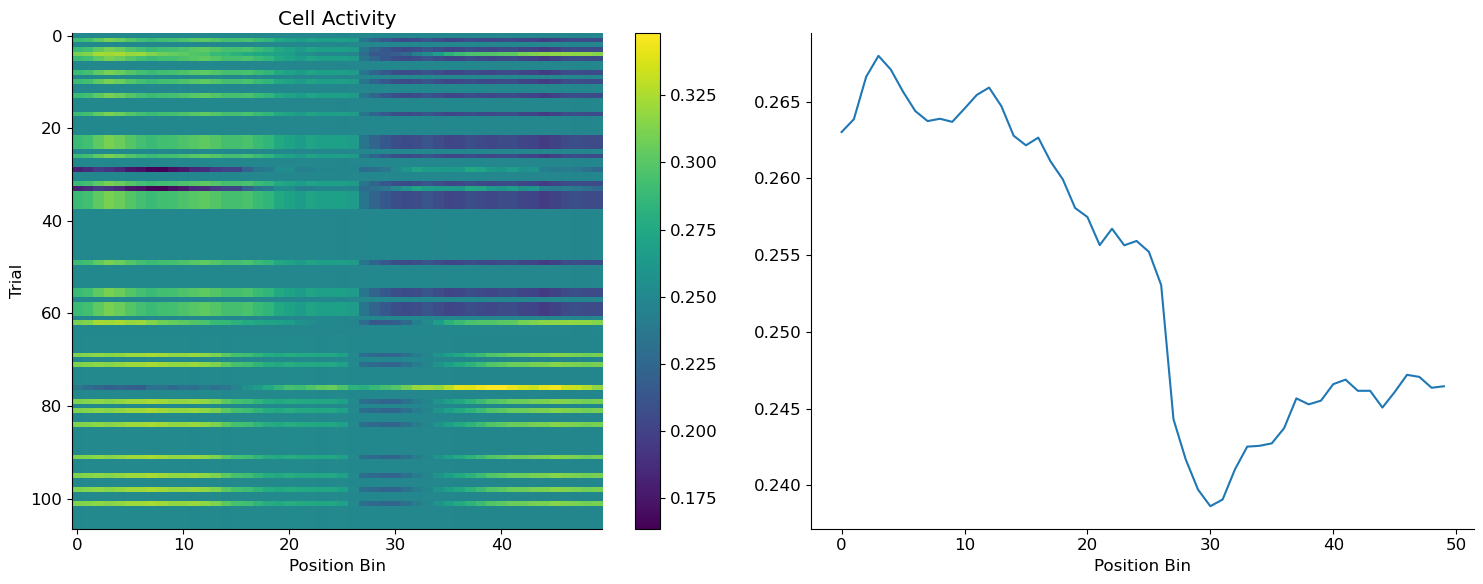

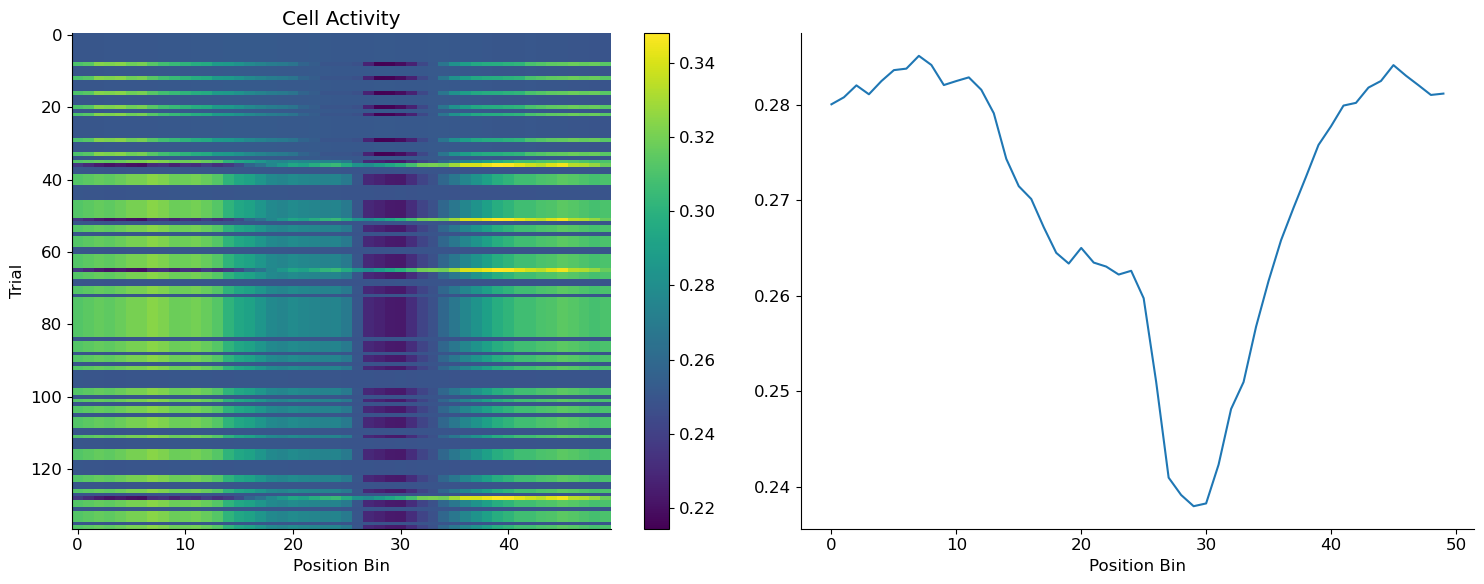

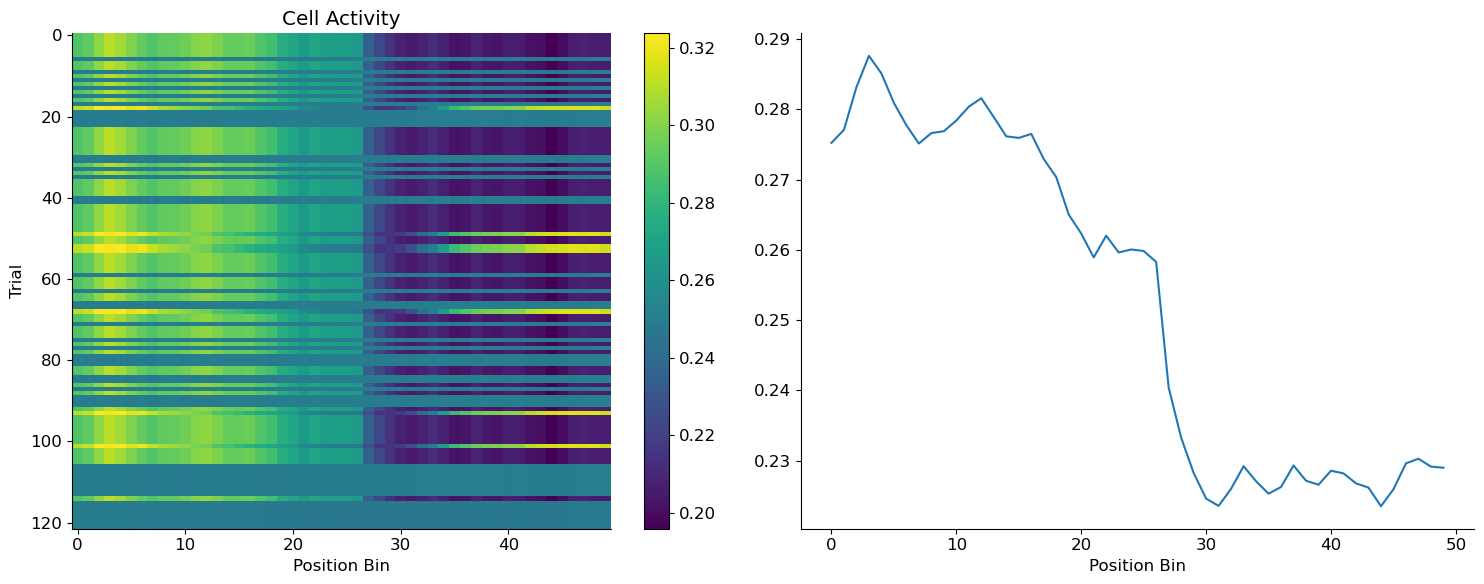

In [70]:

for i in range(10):
    fig, axs = plt.subplots(1,2, figsize=(15,6))
    im=axs[0].imshow(full_activity_list_SST_trough[i].T, aspect='auto')
    fig.colorbar(im, ax=axs[0])
    axs[0].set_title("Cell Activity")
    axs[0].set_ylabel("Trial")
    axs[0].set_xlabel("Position Bin")
    axs[1].plot(np.mean(full_activity_list_SST_trough[i], axis=1))
    axs[1].set_xlabel("Position Bin")
    plt.tight_layout()
    plt.show()
    

In [71]:
num_trials_list = []
for animal in residual_activity_dict_SST:
    for cell in residual_activity_dict_SST[animal]:
        num_trials_list.append(residual_activity_dict_SST[animal][cell].shape[1])

for i in range(len(model_cell_list_SST_trough_early)):
    early = model_cell_list_SST_trough_early[i].shape[1]
    late = model_cell_list_SST_trough_late[i].shape[1]
    full = full_activity_list_SST_trough[i].shape[1]
    print(f"{full} {num_trials_list[i]}")

122 212
207 212
142 212
207 212
182 212
132 152
47 152
107 152
137 152
122 152
122 152
62 152
97 152
62 152
77 152
62 152
97 152
82 152
127 152
87 152
48 73
63 73
68 73
63 73
38 73
28 73
107 137
117 137
97 137
112 137
58 63
58 63
28 63
38 63
58 63
18 63
58 63
28 63
38 63
13 63
43 63
38 63
58 63
118 163
143 163
103 163
103 163
103 163
148 163
143 163
133 163
143 163
103 163
113 163
123 163
118 163
47 82
72 82
62 82
87 177
117 177
167 177
78 83
48 83
58 83
79 149
134 149
94 149
104 149
104 149
139 149
124 149
69 149
84 149
114 149
